<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=322264434" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing

In [2]:
# A GPU will be used, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers = tickers.sort_values(by=['cik','ticker']).drop_duplicates(subset=['cik'],keep='first').set_index('cik')
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv',
                     index_col=['date','ticker'],
                     date_format='ISO8601',
                    ).replace({0.0:np.nan}).dropna()
prices.index.rename(['snapshot','ticker'],inplace=True)
prices

,,exchange,price
snapshot,ticker,,
2010-02-01,A,NYSE - Delayed Quote,20.05
2010-03-01,A,NYSE - Delayed Quote,22.50
2010-04-01,A,NYSE - Delayed Quote,24.60
2010-05-01,A,NYSE - Delayed Quote,25.94
2010-06-01,A,NYSE - Delayed Quote,23.15
...,...,...,...
2026-01-01,ZYME,NasdaqGS - Delayed Quote,26.33
2026-02-01,ZYME,NasdaqGS - Delayed Quote,22.53
2026-03-01,ZYME,NasdaqGS - Delayed Quote,23.29


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages here on Kaggle

In [6]:
keys = ['snapshot','cik','ticker','date']
snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',
                        index_col=keys,
                        usecols=keys+ml_features,
                        date_format='ISO8601',
                        dtype={'cik':str})

# We can only use ciks with a ticker symbol, because the prices dataset is per-ticker.
snapshots = snapshots[snapshots.index.get_level_values('ticker').notna()]

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].index.get_level_values('cik').unique().tolist()
snapshots = snapshots[~snapshots.index.isin(zero_asset_ciks,level='cik')]

# We ensure a window_size number of snapshots of historic data is available for each cik.
ciks_with_history = snapshots.reset_index(level='snapshot').groupby('cik')['snapshot'].count()
ciks_with_history = ciks_with_history[ciks_with_history >= window_size].index.unique().tolist()
snapshots = snapshots[snapshots.index.isin(ciks_with_history, level='cik')]

snapshots = pd.merge(snapshots, prices.drop(columns='exchange'), left_index=True, right_index=True, how='left')
snapshots

Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-05-26 0001948455 ISPR   2026-03-31   0.075911     0.092115   
           0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  
snapshot   cik        ticker date                                     
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68  
           0000001800 ABT    2012-09-30              9.212610  31.43  
           0000002098 ACU    2012-09-30              0.001128  11.04  
           0000002488 AMD    2012-09-29              0.135000   2.40  
           0000002809 AEM    2012-09-30              0.722071  52.46  
...                                                       ...    ...  
2026-05-26 0001948455 ISPR   2026-03-31              0.001501    NaN  
           0001952073 MSGE   2026-03-31              0.341042    NaN  
           0001953366 STHO   2026-03-31             -0.013730    NaN  
           0001955520 KNF    2026-03-31              0.345202    NaN  
           0001964333 BHRB   2026-03-31              0.096788    NaN  

[474337 rows x 4 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in the new column *is_created* whether a row was artificially created or not.

In [7]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates), len(unique_ciks), len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.set_index(['cik','snapshot']).sort_index().drop(columns=['date','ticker'])
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df.info()

There are 160 unique snapshots and 3280 unique ciks for a total of 524800 records.
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 524800 entries, ('0000001750', Timestamp('2013-01-01 00:00:00')) to ('0001964333', Timestamp('2026-04-01 00:00:00'))
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Assets                524800 non-null  float64
 1   Liabilities           524800 non-null  float64
 2   NetCashOperating_ttm  524800 non-null  float64
 3   price                 524800 non-null  float64
 4   is_created            524800 non-null  bool   
dtypes: bool(1), float64(4)
memory usage: 18.7+ MB


The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [8]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [9]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3280, 160, 3])
Labels shape: torch.Size([3280, 160])
Asset multiplier shape: torch.Size([3280])
Cash multiplier shape: torch.Size([160])


device(type='cpu')

Adjusted assets shape: torch.Size([3280, 160])
Adjusted cashflow shape: torch.Size([3280, 160])
Forward shape: torch.Size([3280, 160])
Epoch [1000/6000], Loss=953.13787379
Epoch [2000/6000], Loss=952.27380715
Epoch [3000/6000], Loss=952.02894418
Epoch [4000/6000], Loss=951.89805352
Epoch [5000/6000], Loss=951.99696267
Epoch [6000/6000], Loss=951.96074836


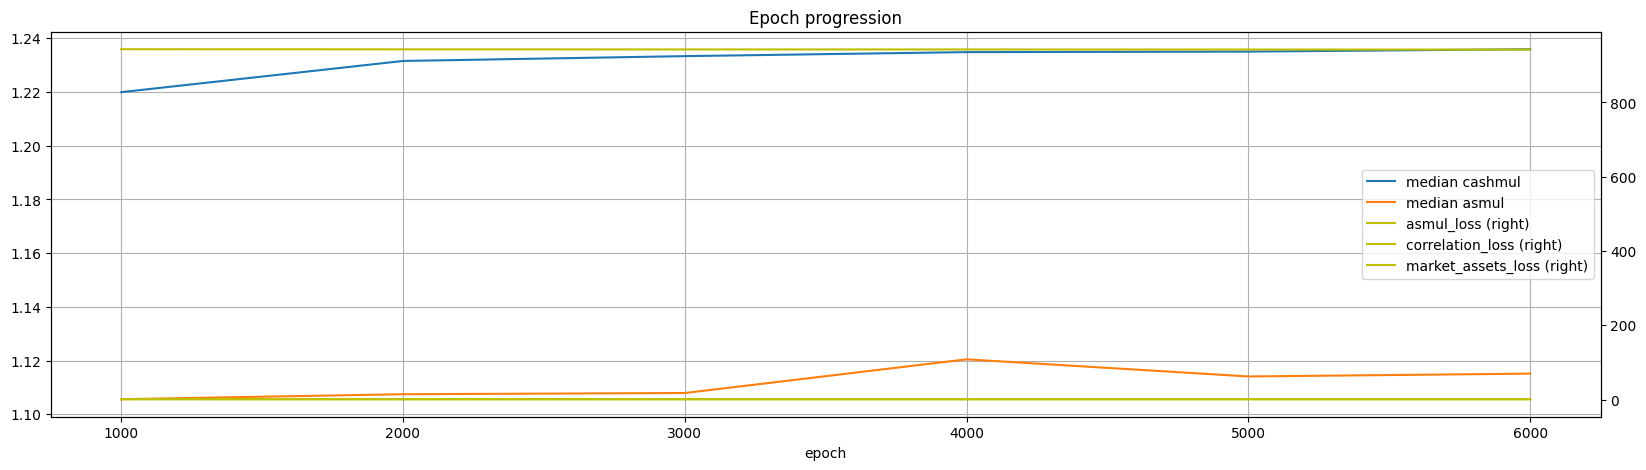

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.219936,1.105599,0.880728,943.215317,1.115271
2000,1.231562,1.107465,0.850881,942.902540,0.862462
3000,1.233357,1.107909,0.852984,942.652896,0.846204
4000,1.234853,1.120457,0.848067,942.562595,0.854785
5000,1.235040,1.114076,0.870107,942.342269,0.953619
6000,1.235931,1.115127,0.869685,942.297519,0.966377


In [10]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [11]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                         
0000001750 2013-01-01  2.189300     1.286500              0.149717  18.68   
           2013-02-01  2.189300     1.286500              0.149717  18.85   
           2013-03-01  2.189300     1.286500              0.149717  17.57   
           2013-04-01  2.217000     1.293000              0.163817  18.39   
           2013-05-01  2.217000     1.293000              0.163817  17.86   
...                         ...          ...                   ...    ...   
0001964333 2025-12-01  7.889037     7.066806              0.153871  65.24   
           2026-01-01  7.889037     7.066806              0.153871  62.31   
           2026-02-01  7.889037     7.066806              0.153871  65.48   
           2026-03-01  7.920626     7.065977              0.107933  64.44   
           2026-04-01  7.920626     7.065977              0.107933  62.29   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2013-01-01  1.021526 -1.372827  0.744391  
           2013-02-01  1.021526 -1.077737  0.788570  
           2013-03-01  1.021526 -0.974335  0.804052  
           2013-04-01  1.021526 -0.782944  0.843463  
           2013-05-01  1.021526 -0.749364  0.848964  
...                         ...       ...       ...  
0001964333 2025-12-01  1.371390  1.479338  3.979767  
           2026-01-01  1.371390  1.496008  3.982332  
           2026-02-01  1.371390  1.663449  4.008096  
           2026-03-01  1.371390  1.726324  3.982617  
           2026-04-01  1.371390  1.537746  3.962263  

[400028 rows x 7 columns]

In [12]:
%%time
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')

# The asset and cash multipliers are not available for the most recent snapshots,
# which are not part of the stock prices dataset.
# We use their latest available values in the model price formula for these recent snapshots. 
result = pd.concat([result.drop(columns=mul_columns),
                    result[mul_columns].groupby('cik',group_keys=False).apply(lambda x:x.interpolate())],
                   axis='columns')

result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(df):
    regressor = linear_model.LinearRegression().fit(X=df['model'].to_frame(), y=df[ml_label])
    return pd.Series({'hype':regressor.coef_[0], 'bias':regressor.intercept_})

result = result.merge(result[['model',ml_label]].dropna().groupby(by=['ticker','cik']).apply(line_fit),
                     left_index=True, right_index=True, how='inner')

result['model_price'] = result['model'] * result['hype'] + result['bias']

# We use the scaled ratio of model price to actual price as overvaluation metric.
result['overvaluation'] = result['model_price'] / result['price']
def interpolate_and_scale(df):
    df['overvaluation'] = -1 * preprocessing.RobustScaler().fit_transform(df['overvaluation'].interpolate().to_frame())
    return df
result = result.groupby('cik',group_keys=False).apply(interpolate_and_scale)

result

CPU times: user 26.4 s, sys: 159 ms, total: 26.5 s
Wall time: 26.5 s


Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-05-26 0001948455 ISPR   2026-03-31   0.075911     0.092115   
           0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  \
snapshot   cik        ticker date                                      
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68   
           0000001800 ABT    2012-09-30              9.212610  31.43   
           0000002098 ACU    2012-09-30              0.001128  11.04   
           0000002488 AMD    2012-09-29              0.135000   2.40   
           0000002809 AEM    2012-09-30              0.722071  52.46   
...                                                       ...    ...   
2026-05-26 0001948455 ISPR   2026-03-31              0.001501    NaN   
           0001952073 MSGE   2026-03-31              0.341042    NaN   
           0001953366 STHO   2026-03-31             -0.013730    NaN   
           0001955520 KNF    2026-03-31              0.345202    NaN   
           0001964333 BHRB   2026-03-31              0.096788    NaN   

                                            asmul   cashmul     model  \
snapshot   cik        ticker date                                       
2013-01-01 0000001750 AIR    2012-11-30  1.021526 -1.372827  0.744391   
           0000001800 ABT    2012-09-30  0.912144 -1.372827  8.809288   
           0000002098 ACU    2012-09-30  0.978531 -1.372827  0.027377   
           0000002488 AMD    2012-09-29  0.208169 -1.372827 -2.848258   
           0000002809 AEM    2012-09-30  0.432824 -1.372827 -0.561103   
...                                           ...       ...       ...   
2026-05-26 0001948455 ISPR   2026-03-31  4.777435  1.537746  0.272853   
           0001952073 MSGE   2026-03-31  1.307798  1.537746  1.174885   
           0001953366 STHO   2026-03-31  1.041757  1.537746  0.237834   
           0001955520 KNF    2026-03-31  0.743371  1.537746  1.110384   
           0001964333 BHRB   2026-03-31  1.371390  1.537746  3.957611   

                                               hype       bias  model_price  \
snapshot   cik        ticker date                                             
2013-01-01 0000001750 AIR    2012-11-30  101.323252 -67.211675     8.212393   
           0000001800 ABT    2012-09-30    2.444476  -0.778024    20.756065   
           0000002098 ACU    2012-09-30  270.491165   7.406844    14.812041   
           0000002488 AMD    2012-09-29   13.164962  51.094161    13.596957   
           0000002809 AEM    2012-09-30   26.942234  26.911342    11.793979   
...                                             ...        ...          ...   
2026-05-26 0001948455 ISPR   2026-03-31    1.392202   3.958111     4.337978   
           0001952073 MSGE   2026-03-31   54.357202   6.674336    70.537807   
           0001953366 STHO   2026-03-31   22.463935   2.544791     7.887475   
           0001955520 KNF    2026-03-31   61.982025  17.251286    86.075108   
           0001964333 BHRB   2026-03-31    3.026262  50.367593    62.344362   

                                         overvaluation  
snapshot   cik        ticker date                       
2013-01-01 0000001750 AIR    2012-11-30       2.020926  
           0000001800 ABT    2012-09-30       1.553883  
           0000002098 ACU    

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

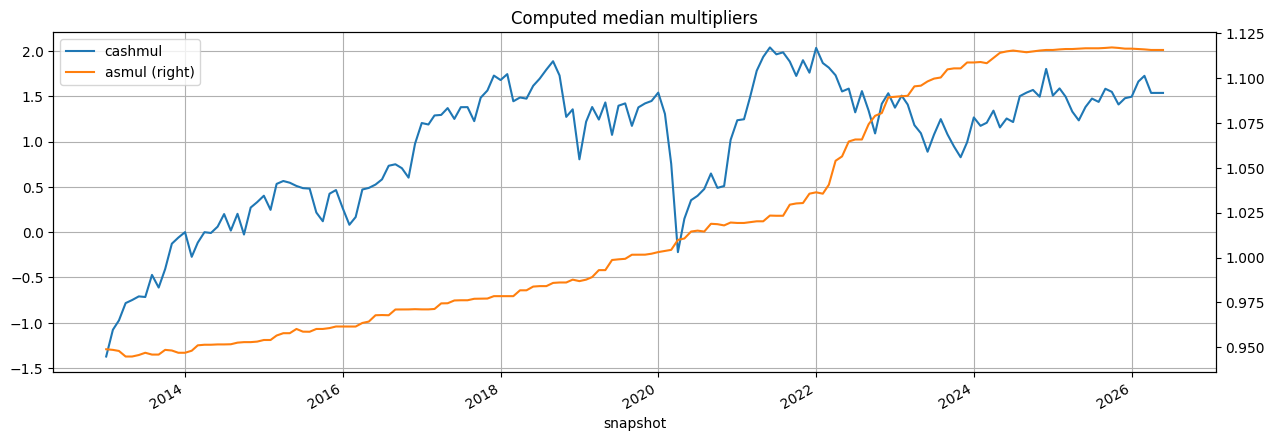

Median asset_multiplier per cik: 1.1154472827911377
Median asset_multiplier per snapshot: 1.0015835762023926


In [13]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

Let's examine the distribution of the achieved correlations:

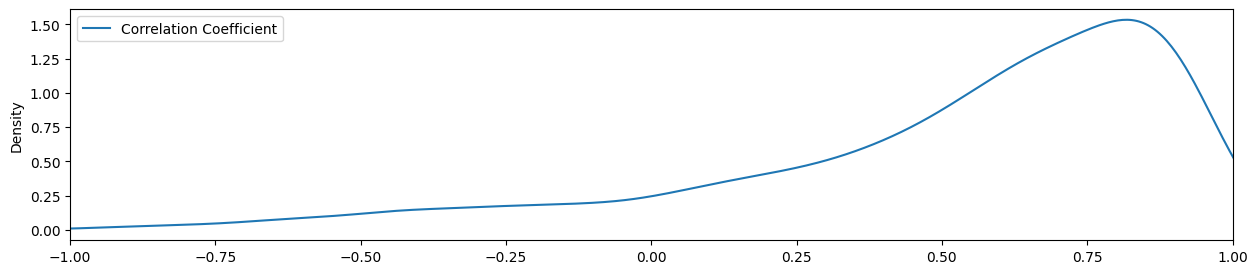

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().unstack().sum(axis='columns')/2 - 1
model_corr = model_corr.rename('Correlation Coefficient').to_frame()
model_corr.plot.density(bw_method=0.2,figsize=(15,3),xlim=(-1,1))
plt.show()

In [15]:
# Reality check for our fair price calculations:
# compute their correlation with the actual prices
result[['price','model_price']].dropna().corr()

,price,model_price
price,1.000000,0.900359
model_price,0.900359,1.000000


In [16]:
# We can now output the results for later use in other models/notebooks/datasets
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

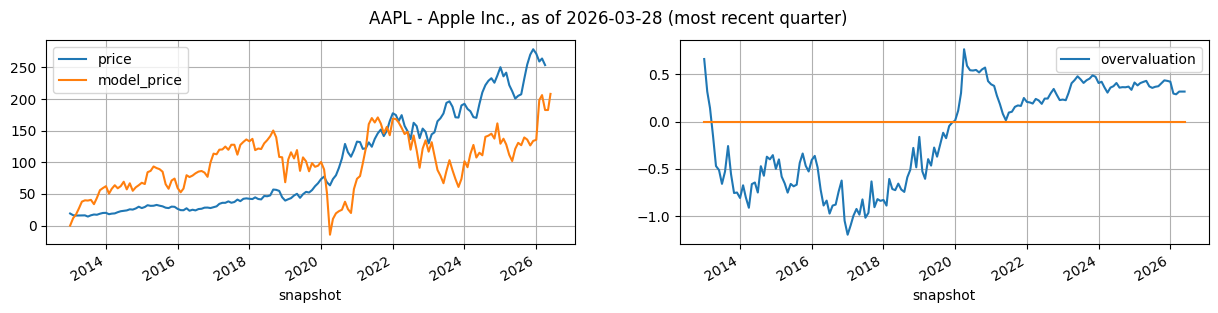

AAPL(0000320193) model_price = 0.923565 * (0.753559 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.802422


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,359.241,285.508,111.482,271.86,0.753559,1.496008,151.979289,0.923565,-4.802422,135.560347,0.420628
2026-02-01,2025-12-27,379.297,291.107,135.472,259.48,0.753559,1.663449,220.066474,0.923565,-4.802422,198.443296,0.295353
2026-03-01,2025-12-27,379.297,291.107,135.472,264.18,0.753559,1.726324,228.584248,0.923565,-4.802422,206.310015,0.287740
2026-04-01,2025-12-27,379.297,291.107,135.472,253.79,0.753559,1.537746,203.037175,0.923565,-4.802422,182.715630,0.316453
2026-05-01,2025-12-27,379.297,291.107,135.472,NaN,0.753559,1.537746,203.037175,0.923565,-4.802422,182.715630,0.316453
2026-05-26,2026-03-28,371.082,264.591,140.222,NaN,0.753559,1.537746,230.666980,0.923565,-4.802422,208.233553,0.316453


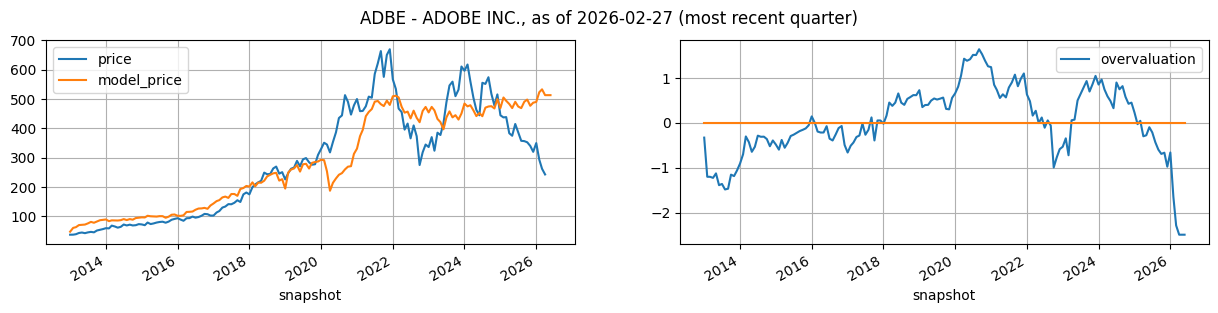

ADBE(0000796343) model_price = 15.474413 * (1.340554 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -70.116190


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-08-29,28.754,16.984,9.792,349.99,1.340554,1.496008,36.211208,15.474413,-70.11619,490.230991,-0.660536
2026-02-01,2025-11-28,29.496,17.873,10.031,293.25,1.340554,1.663449,38.354046,15.474413,-70.11619,523.390150,-1.650812
2026-03-01,2025-11-28,29.496,17.873,10.031,262.41,1.340554,1.726324,38.984743,15.474413,-70.11619,533.149817,-2.287510
2026-04-01,2026-02-27,29.704,18.271,10.507,243.08,1.340554,1.537746,37.705917,15.474413,-70.11619,513.360733,-2.494173
2026-05-01,2026-02-27,29.704,18.271,10.507,NaN,1.340554,1.537746,37.705917,15.474413,-70.11619,513.360733,-2.494173
2026-05-26,2026-02-27,29.704,18.271,10.507,NaN,1.340554,1.537746,37.705917,15.474413,-70.11619,513.360733,-2.494173


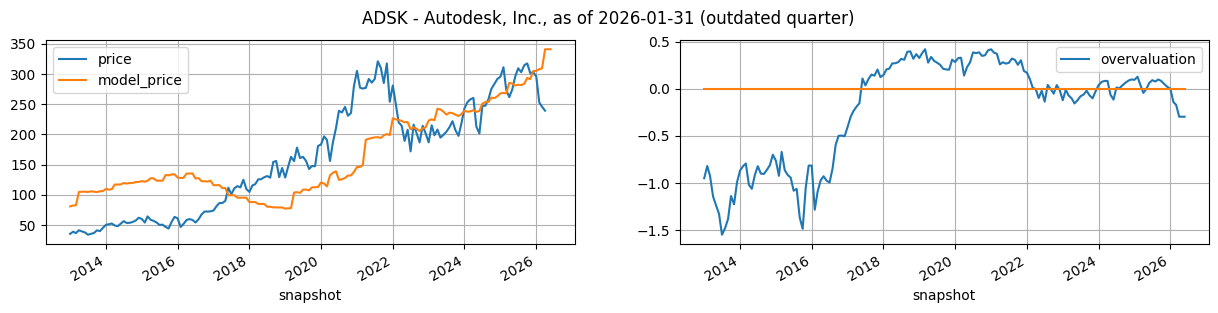

ADSK(0000769397) model_price = 8.241864 * (3.874871 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -10.446721


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-31,11.198,8.305,2.155,296.01,3.874871,1.496008,38.309709,8.241864,-10.446721,305.296671,0.001839
2026-02-01,2025-10-31,11.198,8.305,2.155,252.87,3.874871,1.663449,38.670544,8.241864,-10.446721,308.270627,-0.140221
2026-03-01,2025-10-31,11.198,8.305,2.155,245.87,3.874871,1.726324,38.806039,8.241864,-10.446721,309.387359,-0.169925
2026-04-01,2026-01-31,12.467,9.422,2.452,239.40,3.874871,1.537746,42.656575,8.241864,-10.446721,341.122954,-0.295984
2026-05-01,2026-01-31,12.467,9.422,2.452,NaN,3.874871,1.537746,42.656575,8.241864,-10.446721,341.122954,-0.295984
2026-05-26,2026-01-31,12.467,9.422,2.452,NaN,3.874871,1.537746,42.656575,8.241864,-10.446721,341.122954,-0.295984


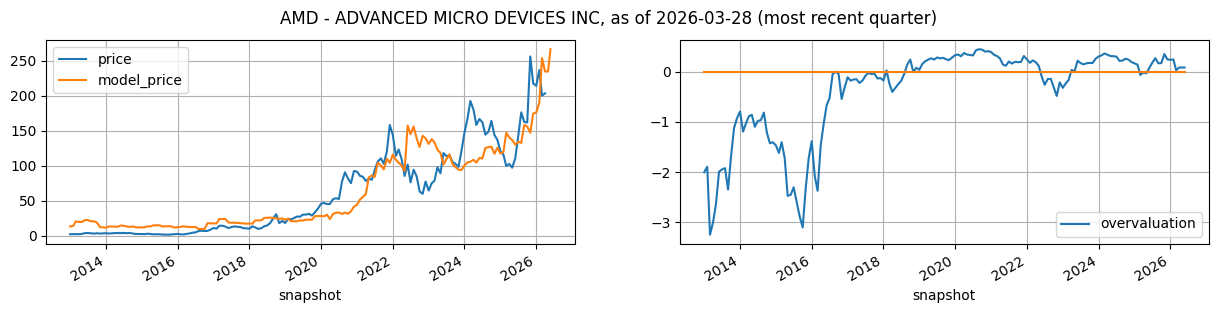

AMD(0000002488) model_price = 13.164962 * (0.208169 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.094161


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,76.891,16.101,6.408,214.16,0.208169,1.496008,9.491719,13.164962,51.094161,176.052277,0.234744
2026-02-01,2025-09-27,76.891,16.101,6.408,236.73,0.208169,1.663449,10.564681,13.164962,51.094161,190.177781,0.243380
2026-03-01,2025-12-27,76.926,13.927,7.709,200.21,0.208169,1.726324,15.394816,13.164962,51.094161,253.766326,0.029118
2026-04-01,2025-12-27,76.926,13.927,7.709,203.43,0.208169,1.537746,13.941066,13.164962,51.094161,234.627767,0.081809
2026-05-01,2025-12-27,76.926,13.927,7.709,NaN,0.208169,1.537746,13.941066,13.164962,51.094161,234.627767,0.081809
2026-05-26,2026-03-28,79.642,15.180,9.725,NaN,0.208169,1.537746,16.353548,13.164962,51.094161,266.387994,0.081809


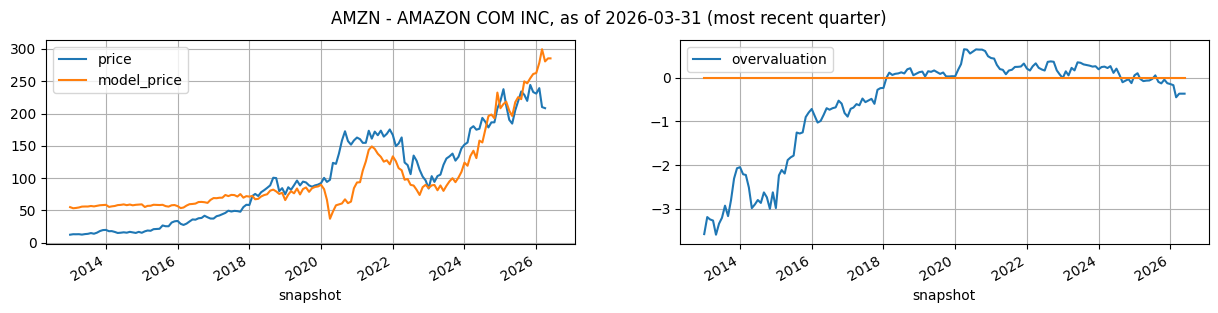

AMZN(0001018724) model_price = 0.690651 * (0.614635 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +60.913915


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,727.921,358.290,135.738750,230.82,0.614635,1.496008,292.181951,0.690651,60.913915,262.709703,-0.141983
2026-02-01,2025-09-30,727.921,358.290,135.738750,239.30,0.614635,1.663449,314.910184,0.690651,60.913915,278.406983,-0.168642
2026-03-01,2025-12-31,818.042,406.977,144.561750,210.00,0.614635,1.726324,345.380601,0.690651,60.913915,299.451410,-0.445680
2026-04-01,2025-12-31,818.042,406.977,144.561750,208.27,0.614635,1.537746,318.119400,0.690651,60.913915,280.623431,-0.362784
2026-05-01,2026-03-31,916.630,474.716,153.635917,NaN,0.614635,1.537746,324.929790,0.690651,60.913915,285.327034,-0.362784
2026-05-26,2026-03-31,916.630,474.716,153.635917,NaN,0.614635,1.537746,324.929790,0.690651,60.913915,285.327034,-0.362784


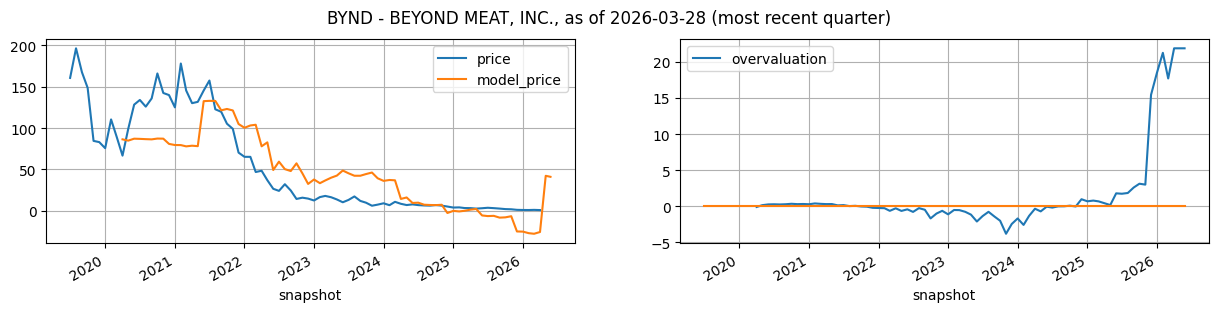

BYND(0001655210) model_price = 88.718111 * (1.743030 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +21.519838


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,0.599669,1.383734,-0.127090,0.820,1.74303,1.496008,-0.528621,88.718111,21.519838,-25.378387,18.499289
2026-02-01,2025-09-27,0.599669,1.383734,-0.127090,0.763,1.74303,1.663449,-0.549901,88.718111,21.519838,-27.266315,21.259663
2026-03-01,2025-09-27,0.599669,1.383734,-0.127090,0.946,1.74303,1.726324,-0.557891,88.718111,21.519838,-27.975240,17.705092
2026-04-01,2025-09-27,0.599669,1.383734,-0.127090,0.702,1.74303,1.537746,-0.533925,88.718111,21.519838,-25.848986,21.886113
2026-05-01,2025-12-31,0.614747,0.615744,-0.144931,NaN,1.74303,1.537746,0.232911,88.718111,21.519838,42.183299,21.886113
2026-05-26,2026-03-28,0.579464,0.600547,-0.123813,NaN,1.74303,1.537746,0.219083,88.718111,21.519838,40.956486,21.886113


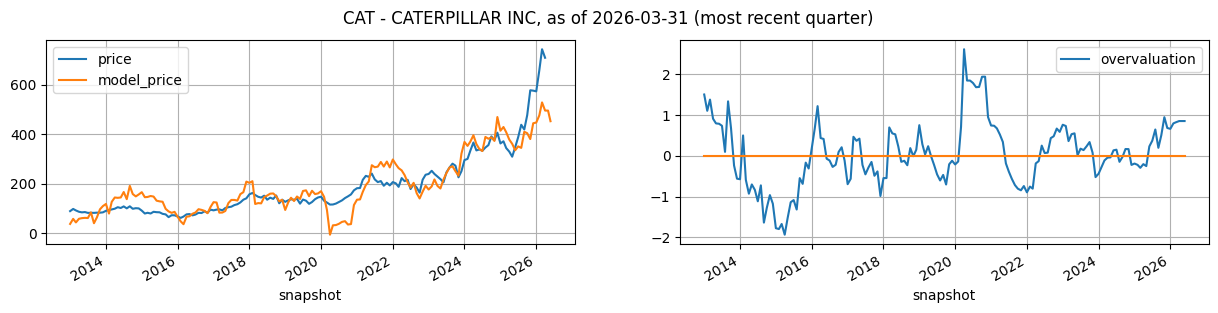

CAT(0000018230) model_price = 14.840876 * (1.372000 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -633.183167


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,93.722,73.063,11.541,572.87,1.372,1.496008,72.788967,14.840876,-633.183167,447.068894,0.659920
2026-02-01,2025-09-30,93.722,73.063,11.541,657.36,1.372,1.663449,74.721404,14.840876,-633.183167,475.747948,0.793487
2026-03-01,2025-12-31,98.585,77.267,11.739,742.83,1.372,1.726324,78.256888,14.840876,-633.183167,528.217625,0.823268
2026-04-01,2025-12-31,98.585,77.267,11.739,708.46,1.372,1.537746,76.043168,14.840876,-633.183167,495.364079,0.851254
2026-05-01,2025-12-31,98.585,77.267,11.739,NaN,1.372,1.537746,76.043168,14.840876,-633.183167,495.364079,0.851254
2026-05-26,2026-03-31,95.550,76.890,12.320,NaN,1.372,1.537746,73.149580,14.840876,-633.183167,452.420694,0.851254


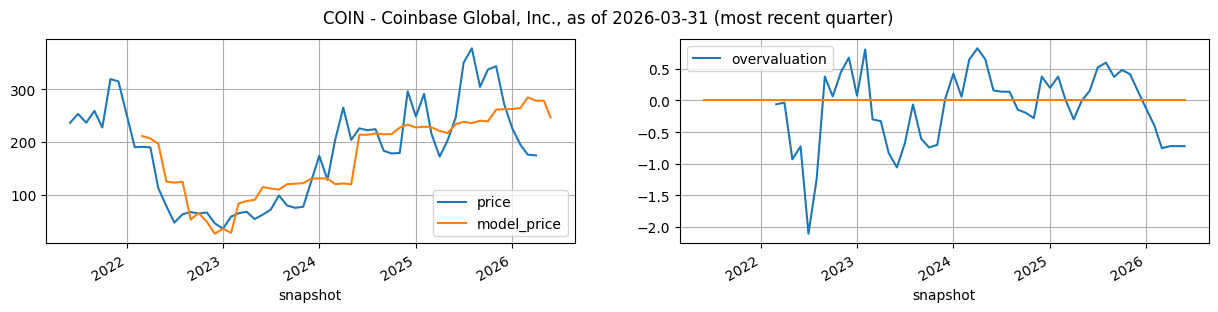

COIN(0001679788) model_price = 13.574373 * (1.015486 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +20.661404


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,31.351367,15.328143,0.872941,226.14,1.015486,1.496008,17.814647,13.574373,20.661404,262.484065,-0.132773
2026-02-01,2025-09-30,31.351367,15.328143,0.872941,194.74,1.015486,1.663449,17.960813,13.574373,20.661404,264.468179,-0.401357
2026-03-01,2025-12-31,29.671832,14.878774,2.426383,175.85,1.015486,1.726324,19.441269,13.574373,20.661404,284.564433,-0.755441
2026-04-01,2025-12-31,29.671832,14.878774,2.426383,174.61,1.015486,1.537746,18.983705,13.574373,20.661404,278.353302,-0.722669
2026-05-01,2025-12-31,29.671832,14.878774,2.426383,NaN,1.015486,1.537746,18.983705,13.574373,20.661404,278.353302,-0.722669
2026-05-26,2026-03-31,28.848792,15.368219,1.756433,NaN,1.015486,1.537746,16.628262,13.574373,20.661404,246.379639,-0.722669


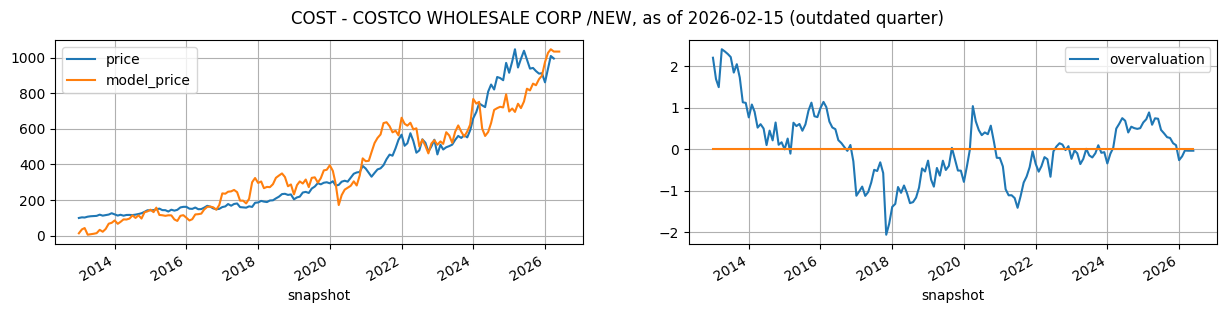

COST(0000909832) model_price = 21.241434 * (1.015828 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -164.465130


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-23,82.790,52.487,14.763,862.34,1.015828,1.496008,53.698999,21.241434,-164.46513,976.178605,-0.267401
2026-02-01,2025-11-23,82.790,52.487,14.763,940.25,1.015828,1.663449,56.170931,21.241434,-164.46513,1028.685978,-0.174252
2026-03-01,2025-11-23,82.790,52.487,14.763,1010.79,1.015828,1.726324,57.099151,21.241434,-164.46513,1048.402714,-0.034746
2026-04-01,2026-02-15,83.639,51.552,15.011,996.43,1.015828,1.537746,56.493970,21.241434,-164.46513,1035.547792,-0.039769
2026-05-01,2026-02-15,83.639,51.552,15.011,NaN,1.015828,1.537746,56.493970,21.241434,-164.46513,1035.547792,-0.039769
2026-05-26,2026-02-15,83.639,51.552,15.011,NaN,1.015828,1.537746,56.493970,21.241434,-164.46513,1035.547792,-0.039769


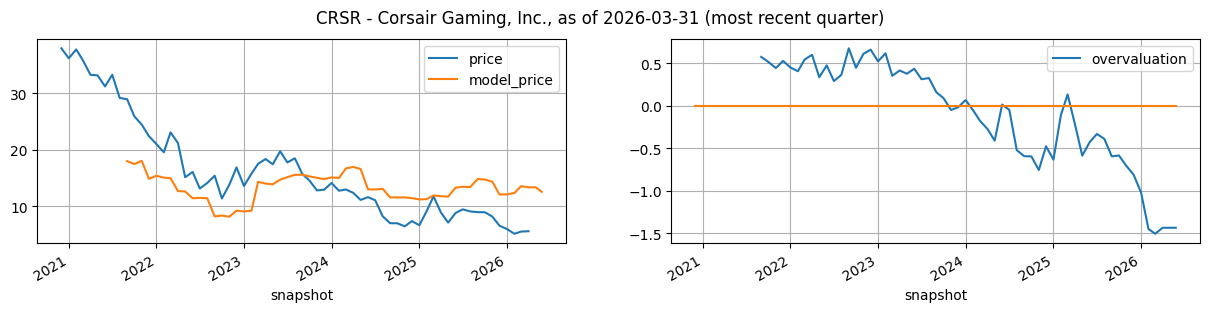

CRSR(0001743759) model_price = 21.094909 * (1.907081 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -25.641708


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,1.198499,0.598269,0.067507,5.94,1.907081,1.496008,1.788357,21.094909,-25.641708,12.083513,-1.017750
2026-02-01,2025-09-30,1.198499,0.598269,0.067507,5.10,1.907081,1.663449,1.799660,21.094909,-25.641708,12.321958,-1.448558
2026-03-01,2025-12-31,1.253784,0.620227,0.050121,5.49,1.907081,1.726324,1.857366,21.094909,-25.641708,13.539252,-1.505083
2026-04-01,2025-12-31,1.253784,0.620227,0.050121,5.55,1.907081,1.537746,1.847914,21.094909,-25.641708,13.339869,-1.434464
2026-05-01,2025-12-31,1.253784,0.620227,0.050121,NaN,1.907081,1.537746,1.847914,21.094909,-25.641708,13.339869,-1.434464
2026-05-26,2026-03-31,1.177340,0.529698,0.061099,NaN,1.907081,1.537746,1.809539,21.094909,-25.641708,12.530362,-1.434464


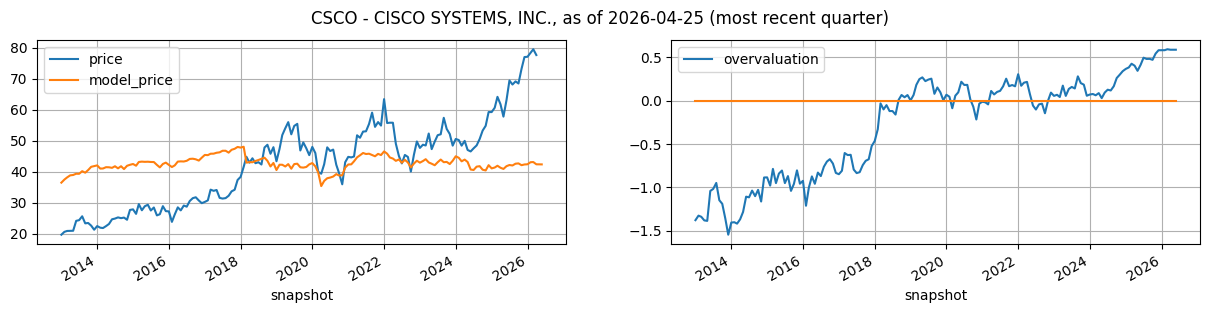

CSCO(0000858877) model_price = 0.288646 * (0.642346 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +35.399865


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-25,121.102,74.229,13.744,77.03,0.642346,1.496008,24.121524,0.288646,35.399865,42.362444,0.579182
2026-02-01,2025-10-25,121.102,74.229,13.744,78.32,0.642346,1.663449,26.422834,0.288646,35.399865,43.026707,0.580047
2026-03-01,2026-01-24,123.371,75.648,13.325,79.46,0.642346,1.726324,26.602138,0.288646,35.399865,43.078463,0.590891
2026-04-01,2026-01-24,123.371,75.648,13.325,77.59,0.642346,1.537746,24.089333,0.288646,35.399865,42.353152,0.585315
2026-05-01,2026-01-24,123.371,75.648,13.325,NaN,0.642346,1.537746,24.089333,0.288646,35.399865,42.353152,0.585315
2026-05-26,2026-04-25,125.546,76.685,13.025,NaN,0.642346,1.537746,23.988112,0.288646,35.399865,42.323935,0.585315


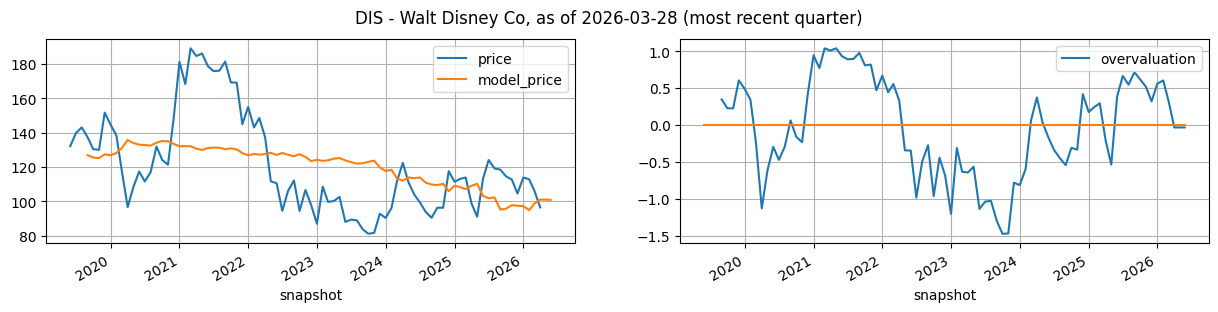

DIS(0001744489) model_price = -0.789063 * (0.917109 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +192.288621


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,197.514,87.645,18.101,113.77,0.917109,1.496008,120.576160,-0.789063,192.288621,97.146430,0.559530
2026-02-01,2025-09-27,197.514,87.645,18.101,112.80,0.917109,1.663449,123.607010,-0.789063,192.288621,94.754898,0.602083
2026-03-01,2025-12-27,202.089,93.613,15.631,106.04,0.917109,1.726324,118.708861,-0.789063,192.288621,98.619846,0.325743
2026-04-01,2025-12-27,202.089,93.613,15.631,96.38,0.917109,1.537746,115.761195,-0.789063,192.288621,100.945741,-0.034569
2026-05-01,2025-12-27,202.089,93.613,15.631,NaN,0.917109,1.537746,115.761195,-0.789063,192.288621,100.945741,-0.034569
2026-05-26,2026-03-28,205.217,96.509,15.792,NaN,0.917109,1.537746,115.981489,-0.789063,192.288621,100.771915,-0.034569


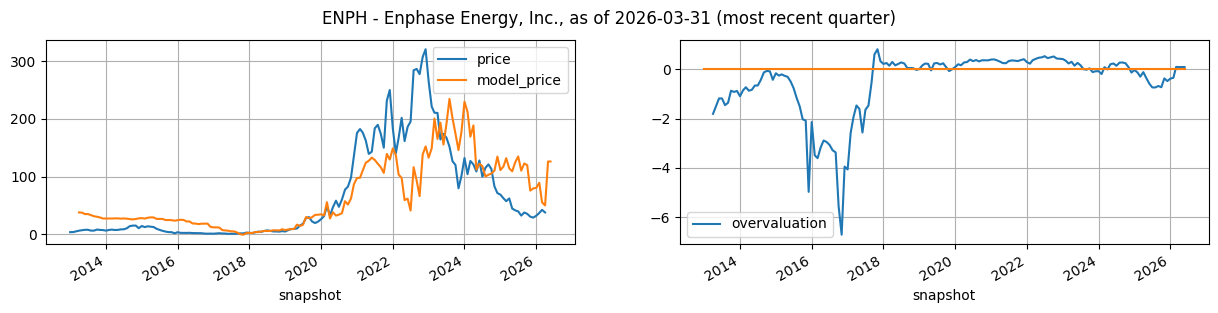

ENPH(0001463101) model_price = 208.464001 * (0.661354 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.360794


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,3.320488,2.325466,0.256253,32.05,0.661354,1.496008,0.253910,208.464001,27.360794,80.291848,-0.380871
2026-02-01,2025-09-30,3.320488,2.325466,0.256253,36.98,0.661354,1.663449,0.296817,208.464001,27.360794,89.236467,-0.344339
2026-03-01,2025-12-31,3.509792,2.422769,0.136540,42.27,0.661354,1.726324,0.134160,208.464001,27.360794,55.328226,0.093608
2026-04-01,2025-12-31,3.509792,2.422769,0.136540,37.81,0.661354,1.537746,0.108411,208.464001,27.360794,49.960596,0.088676
2026-05-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.661354,1.537746,0.473612,208.464001,27.360794,126.091884,0.088676
2026-05-26,2026-03-31,2.723923,1.621571,0.190997,NaN,0.661354,1.537746,0.473612,208.464001,27.360794,126.091884,0.088676


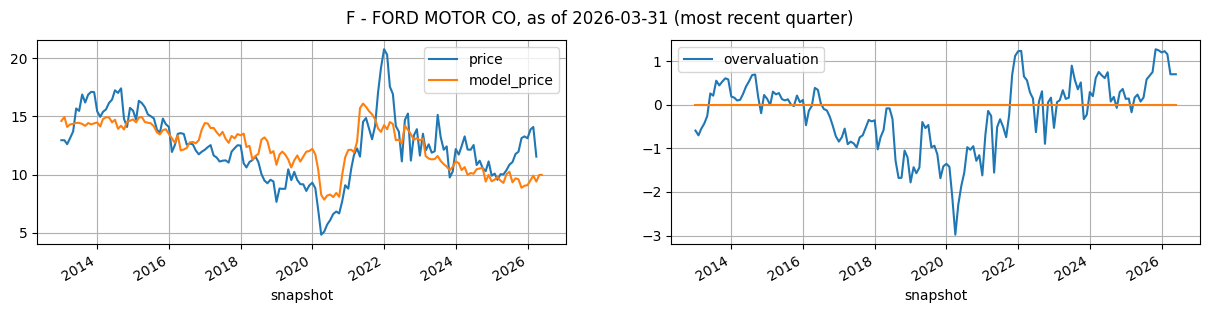

F(0000037996) model_price = 0.126880 * (0.009479 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +37.022328


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,300.990,253.598,20.426,13.12,0.009479,1.496008,-220.187326,0.12688,37.022328,9.084925,1.201518
2026-02-01,2025-09-30,300.990,253.598,20.426,13.88,0.009479,1.663449,-216.767176,0.12688,37.022328,9.518874,1.228922
2026-03-01,2025-12-31,289.160,253.208,21.282,14.09,0.009479,1.726324,-213.727304,0.12688,37.022328,9.904574,1.158244
2026-04-01,2025-12-31,289.160,253.208,21.282,11.54,0.009479,1.537746,-217.740626,0.12688,37.022328,9.395363,0.700022
2026-05-01,2026-03-31,282.434,244.981,18.919,NaN,0.009479,1.537746,-213.211078,0.12688,37.022328,9.970072,0.700022
2026-05-26,2026-03-31,282.434,244.981,18.919,NaN,0.009479,1.537746,-213.211078,0.12688,37.022328,9.970072,0.700022


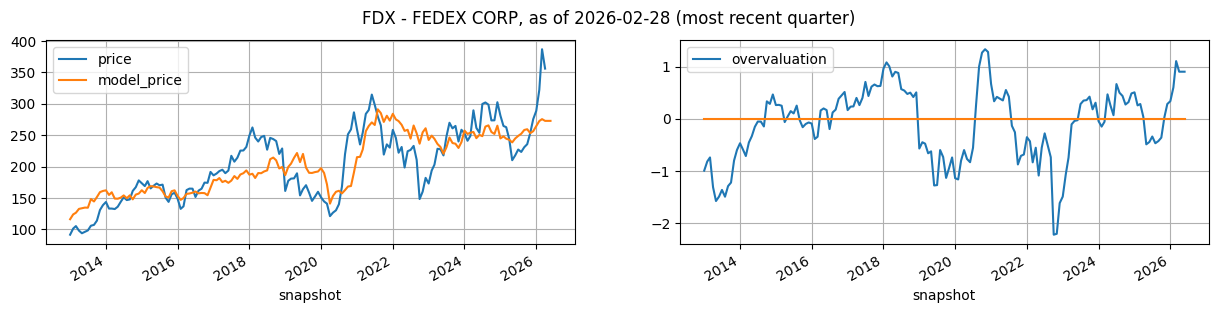

FDX(0001048911) model_price = 5.911242 * (0.899654 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +78.629601


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-30,89.181,61.041,8.198,288.86,0.899654,1.496008,31.455294,5.911242,78.629601,264.569447,0.337606
2026-02-01,2025-11-30,89.181,61.041,8.198,322.25,0.899654,1.663449,32.827976,5.911242,78.629601,272.683698,0.600631
2026-03-01,2025-11-30,89.181,61.041,8.198,387.00,0.899654,1.726324,33.343423,5.911242,78.629601,275.730633,1.105029
2026-04-01,2026-02-28,94.733,64.929,8.179,356.18,0.899654,1.537746,32.875119,5.911242,78.629601,272.962375,0.901773
2026-05-01,2026-02-28,94.733,64.929,8.179,NaN,0.899654,1.537746,32.875119,5.911242,78.629601,272.962375,0.901773
2026-05-26,2026-02-28,94.733,64.929,8.179,NaN,0.899654,1.537746,32.875119,5.911242,78.629601,272.962375,0.901773


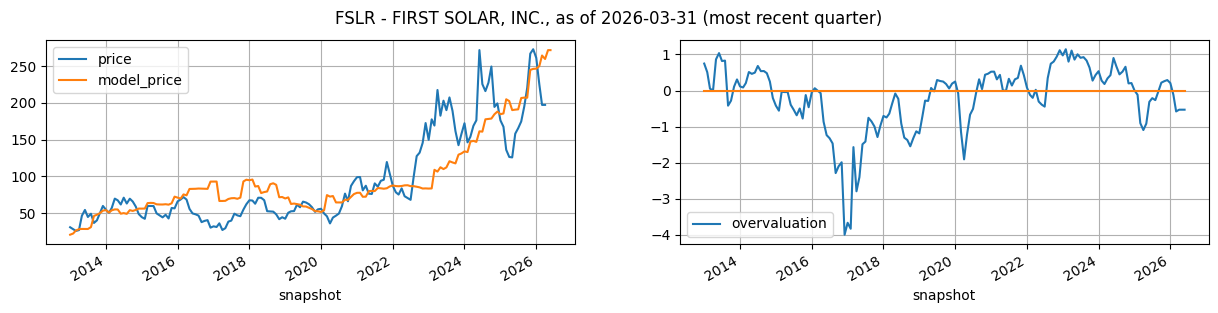

FSLR(0001274494) model_price = 12.235298 * (2.318119 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -110.584250


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,13.459309,4.443997,1.626208,261.23,2.31812,1.496008,29.189110,12.235298,-110.58425,246.553214,0.208394
2026-02-01,2025-09-30,13.459309,4.443997,1.626208,225.52,2.31812,1.663449,29.461404,12.235298,-110.58425,249.884811,-0.117006
2026-03-01,2025-12-31,13.321310,3.783317,2.057105,197.20,2.31812,1.726324,30.648301,12.235298,-110.58425,264.406851,-0.578225
2026-04-01,2025-12-31,13.321310,3.783317,2.057105,197.26,2.31812,1.537746,30.260376,12.235298,-110.58425,259.660470,-0.529740
2026-05-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.31812,1.537746,31.244726,12.235298,-110.58425,271.704288,-0.529740
2026-05-26,2026-03-31,13.351097,3.472529,2.450221,NaN,2.31812,1.537746,31.244726,12.235298,-110.58425,271.704288,-0.529740


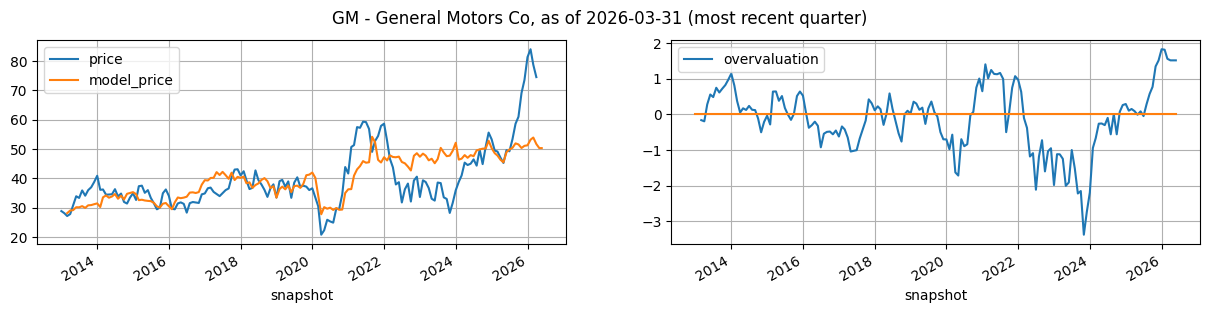

GM(0001467858) model_price = 0.436600 * (0.828904 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.981172


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,288.168,221.794,24.212,81.32,0.828904,1.496008,53.291036,0.4366,27.981172,51.248030,1.831452
2026-02-01,2025-12-31,281.284,220.165,26.867,84.00,0.828904,1.663449,57.684398,0.4366,27.981172,53.166171,1.818077
2026-03-01,2025-12-31,281.284,220.165,26.867,78.71,0.828904,1.726324,59.373655,0.4366,27.981172,53.903701,1.563619
2026-04-01,2025-12-31,281.284,220.165,26.867,74.50,0.828904,1.537746,54.307123,0.4366,27.981172,51.691654,1.519460
2026-05-01,2026-03-31,280.974,218.315,23.756,NaN,0.828904,1.537746,51.116236,0.4366,27.981172,50.298513,1.519460
2026-05-26,2026-03-31,280.974,218.315,23.756,NaN,0.828904,1.537746,51.116236,0.4366,27.981172,50.298513,1.519460


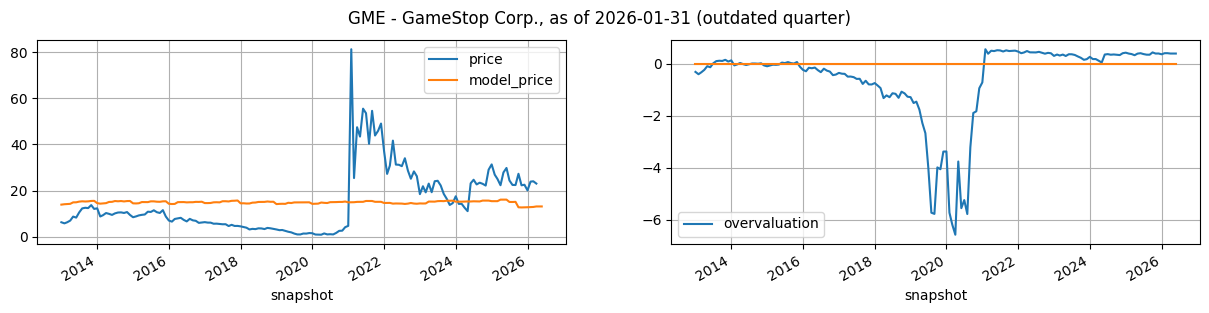

GME(0001326380) model_price = 0.910742 * (0.001245 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.751457


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-01,10.5507,5.2477,0.5835,20.08,0.001245,1.496008,-4.361642,0.910742,16.751457,12.779129,0.355787
2026-02-01,2025-11-01,10.5507,5.2477,0.5835,23.88,0.001245,1.663449,-4.263940,0.910742,16.751457,12.868110,0.397517
2026-03-01,2025-11-01,10.5507,5.2477,0.5835,24.03,0.001245,1.726324,-4.227253,0.910742,16.751457,12.901522,0.398361
2026-04-01,2026-01-31,10.3884,4.9440,0.6148,23.04,0.001245,1.537746,-3.985659,0.910742,16.751457,13.121552,0.384406
2026-05-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.001245,1.537746,-3.985659,0.910742,16.751457,13.121552,0.384406
2026-05-26,2026-01-31,10.3884,4.9440,0.6148,NaN,0.001245,1.537746,-3.985659,0.910742,16.751457,13.121552,0.384406


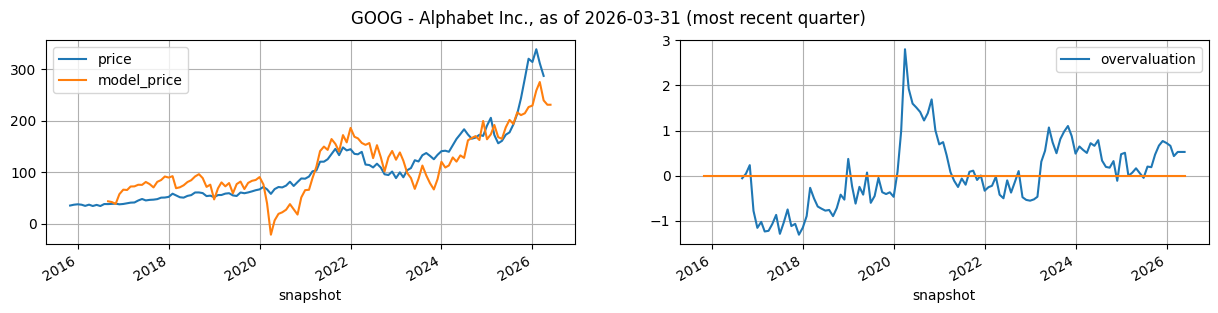

GOOG(0001652044) model_price = 1.145933 * (0.211296 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +11.296805


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,536.469,149.602,151.424,313.80,0.211296,1.496008,190.283513,1.145933,11.296805,229.348976,0.723223
2026-02-01,2025-09-30,536.469,149.602,151.424,338.53,0.211296,1.663449,215.638100,1.145933,11.296805,258.403636,0.661549
2026-03-01,2025-12-31,595.281,180.016,164.713,311.43,0.211296,1.726324,230.112737,1.145933,11.296805,274.990601,0.433973
2026-04-01,2025-12-31,595.281,180.016,164.713,286.86,0.211296,1.537746,199.051448,1.145933,11.296805,239.396442,0.526105
2026-05-01,2026-03-31,703.919,225.173,174.353,NaN,0.211296,1.537746,191.673136,1.145933,11.296805,230.941391,0.526105
2026-05-26,2026-03-31,703.919,225.173,174.353,NaN,0.211296,1.537746,191.673136,1.145933,11.296805,230.941391,0.526105


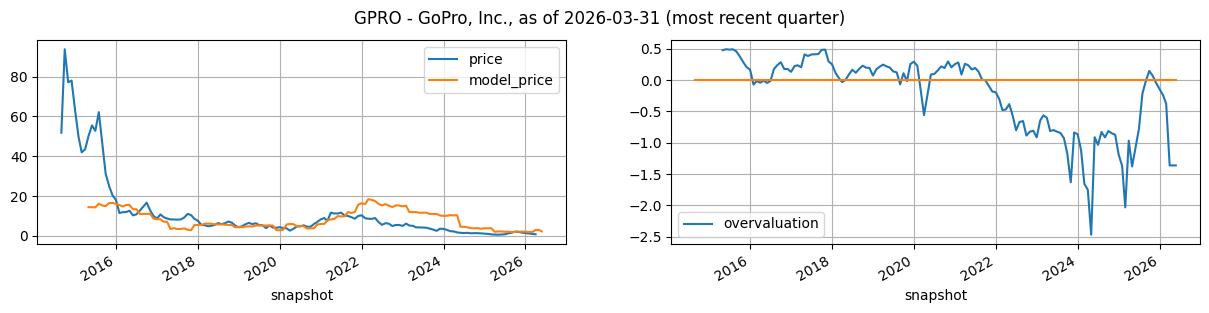

GPRO(0001500435) model_price = 15.542093 * (1.006124 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +2.228721


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,0.538608,0.458114,-0.061371,1.410,1.006124,1.496008,-0.008019,15.542093,2.228721,2.104090,-0.142889
2026-02-01,2025-09-30,0.538608,0.458114,-0.061371,1.160,1.006124,1.663449,-0.018295,15.542093,2.228721,1.944379,-0.237888
2026-03-01,2025-09-30,0.538608,0.458114,-0.061371,0.968,1.006124,1.726324,-0.022154,15.542093,2.228721,1.884407,-0.377609
2026-04-01,2025-12-31,0.427983,0.351433,-0.020669,0.770,1.006124,1.537746,0.047387,15.542093,2.228721,2.965221,-1.361156
2026-05-01,2025-12-31,0.427983,0.351433,-0.020669,NaN,1.006124,1.537746,0.047387,15.542093,2.228721,2.965221,-1.361156
2026-05-26,2026-03-31,0.381355,0.383224,-0.000101,NaN,1.006124,1.537746,0.000311,15.542093,2.228721,2.233558,-1.361156


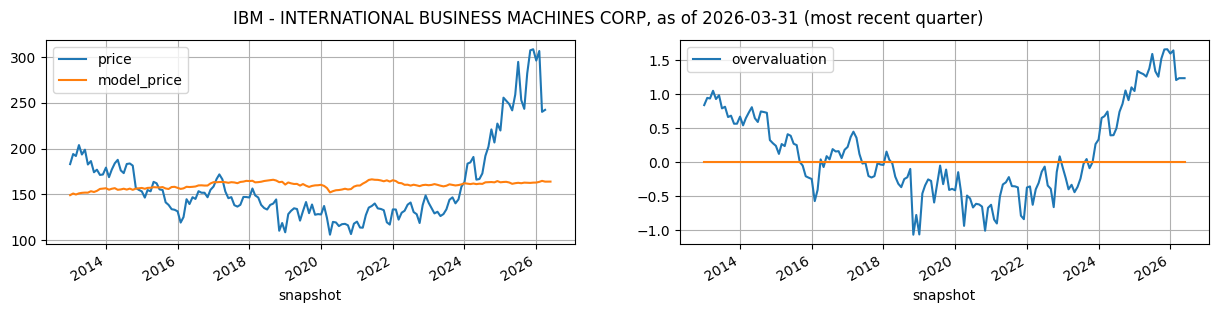

IBM(0000051143) model_price = 0.332162 * (0.668878 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +163.125574


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,146.312,118.407,13.483,296.21,0.668878,1.496008,-0.371406,0.332162,163.125574,163.002207,1.594644
2026-02-01,2025-09-30,146.312,118.407,13.483,306.70,0.668878,1.663449,1.886201,0.332162,163.125574,163.752099,1.641507
2026-03-01,2025-12-31,151.880,119.232,13.193,240.21,0.668878,1.726324,5.132622,0.332162,163.125574,164.830438,1.205748
2026-04-01,2025-12-31,151.880,119.232,13.193,242.39,0.668878,1.537746,2.644709,0.332162,163.125574,164.004047,1.233164
2026-05-01,2026-03-31,156.229,123.255,13.992,NaN,0.668878,1.537746,2.759319,0.332162,163.125574,164.042116,1.233164
2026-05-26,2026-03-31,156.229,123.255,13.992,NaN,0.668878,1.537746,2.759319,0.332162,163.125574,164.042116,1.233164


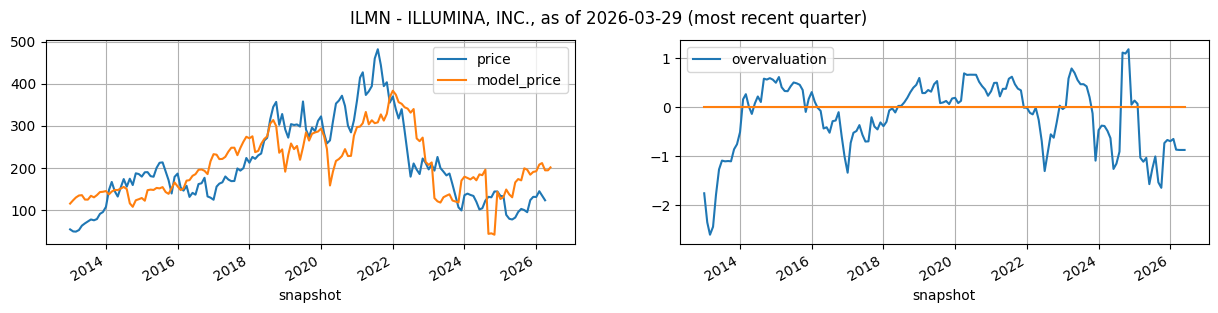

ILMN(0001110803) model_price = 84.483474 * (0.366533 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +179.856035


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-28,6.177,3.796,1.122,131.16,0.366533,1.496008,0.146599,84.483474,179.856035,192.241187,-0.694008
2026-02-01,2025-09-28,6.177,3.796,1.122,144.81,0.366533,1.663449,0.334467,84.483474,179.856035,208.112997,-0.648552
2026-03-01,2025-12-28,6.644,3.921,1.079,134.46,0.366533,1.726324,0.376952,84.483474,179.856035,211.702254,-0.867144
2026-04-01,2025-12-28,6.644,3.921,1.079,123.26,0.366533,1.537746,0.173476,84.483474,179.856035,194.511901,-0.872874
2026-05-01,2025-12-28,6.644,3.921,1.079,NaN,0.366533,1.537746,0.173476,84.483474,179.856035,194.511901,-0.872874
2026-05-26,2026-03-29,6.559,3.883,1.128,NaN,0.366533,1.537746,0.255670,84.483474,179.856035,201.455952,-0.872874


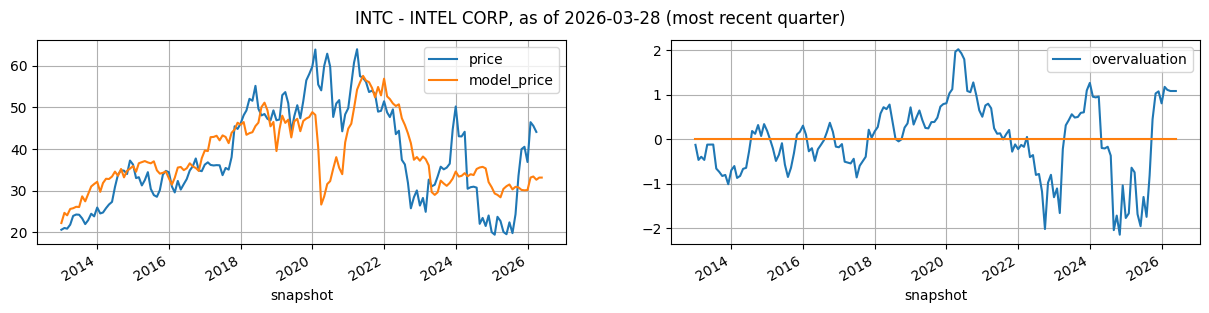

INTC(0000050863) model_price = 0.425774 * (0.399720 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +31.673532


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,204.514,98.138,8.574,36.90,0.39972,1.496008,-3.562967,0.425774,31.673532,30.156514,0.809378
2026-02-01,2025-12-27,211.429,97.148,9.697,46.47,0.39972,1.663449,3.494787,0.425774,31.673532,33.161521,1.179754
2026-03-01,2025-12-27,211.429,97.148,9.697,45.61,0.39972,1.726324,4.104484,0.425774,31.673532,33.421113,1.111328
2026-04-01,2025-12-27,211.429,97.148,9.697,44.13,0.39972,1.537746,2.275841,0.425774,31.673532,32.642525,1.086556
2026-05-01,2026-03-28,205.332,93.938,9.980,NaN,0.39972,1.537746,3.483932,0.425774,31.673532,33.156899,1.086556
2026-05-26,2026-03-28,205.332,93.938,9.980,NaN,0.39972,1.537746,3.483932,0.425774,31.673532,33.156899,1.086556


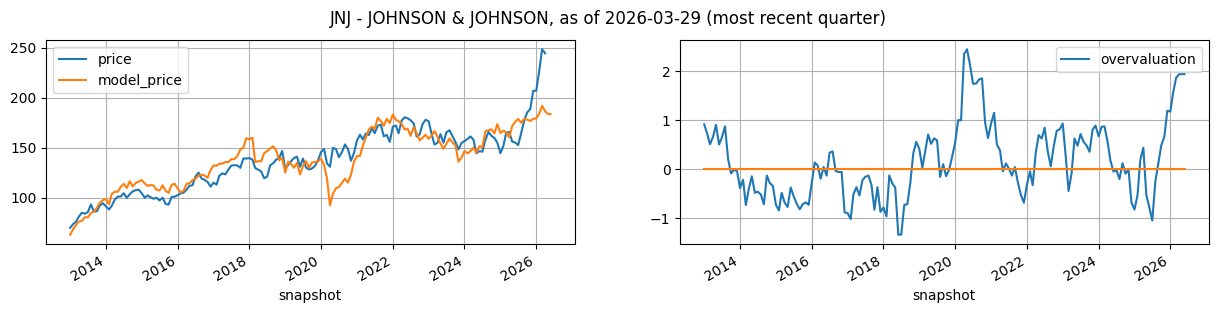

JNJ(0000200406) model_price = 1.189956 * (1.333710 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -34.553310


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-28,192.816,113.539,24.204,206.95,1.33371,1.496008,179.831046,1.189956,-34.55331,179.437693,1.173067
2026-02-01,2025-09-28,192.816,113.539,24.204,227.25,1.33371,1.663449,183.883788,1.189956,-34.55331,184.260277,1.584821
2026-03-01,2025-12-28,199.210,117.666,24.530,248.43,1.33371,1.726324,190.369134,1.189956,-34.55331,191.977552,1.863536
2026-04-01,2025-12-28,199.210,117.666,24.530,244.44,1.33371,1.537746,185.743310,1.189956,-34.55331,186.473025,1.936065
2026-05-01,2026-03-29,200.894,119.708,22.870,NaN,1.33371,1.537746,183.394620,1.189956,-34.55331,183.678188,1.936065
2026-05-26,2026-03-29,200.894,119.708,22.870,NaN,1.33371,1.537746,183.394620,1.189956,-34.55331,183.678188,1.936065


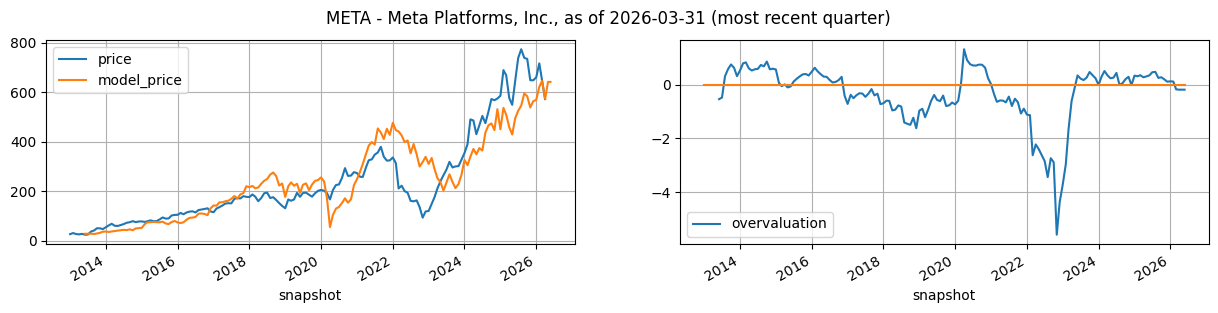

META(0001326801) model_price = 3.330011 * (0.369362 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.164130


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,303.844,109.778,107.574,660.09,0.369362,1.496008,163.382108,3.330011,25.16413,569.228321,0.130536
2026-02-01,2025-12-31,366.021,148.778,115.800,716.50,0.369362,1.663449,179.043781,3.330011,25.16413,621.381863,0.119548
2026-03-01,2025-12-31,366.021,148.778,115.800,648.18,0.369362,1.726324,186.324682,3.330011,25.16413,645.627343,-0.169511
2026-04-01,2025-12-31,366.021,148.778,115.800,572.13,0.369362,1.537746,164.487321,3.330011,25.16413,572.908694,-0.181403
2026-05-01,2026-03-31,395.250,151.569,124.000,NaN,0.369362,1.537746,185.101927,3.330011,25.16413,641.555556,-0.181403
2026-05-26,2026-03-31,395.250,151.569,124.000,NaN,0.369362,1.537746,185.101927,3.330011,25.16413,641.555556,-0.181403


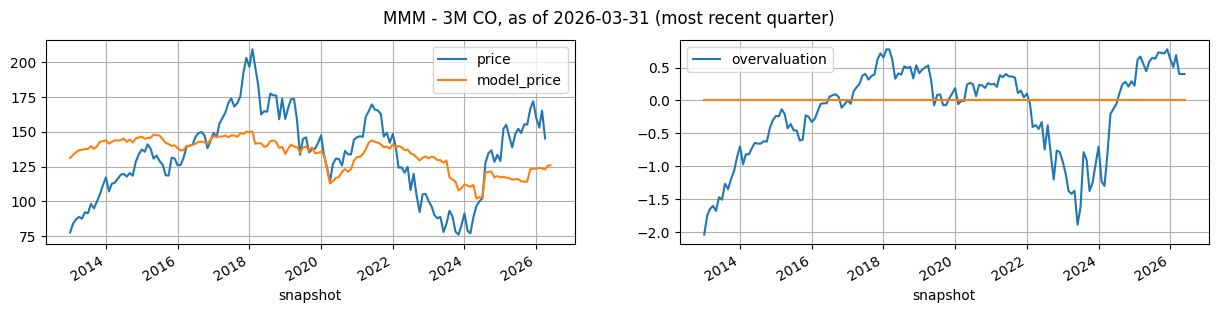

MMM(0000066740) model_price = 1.526422 * (0.002222 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +167.900263


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,37.611,32.983,2.541,160.10,0.002222,1.496008,-29.098065,1.526422,167.900263,123.484341,0.622016
2026-02-01,2025-09-30,37.611,32.983,2.541,153.16,0.002222,1.663449,-28.672598,1.526422,167.900263,124.133784,0.508587
2026-03-01,2025-12-31,37.733,33.031,2.306,165.32,0.002222,1.726324,-28.966248,1.526422,167.900263,123.685550,0.688983
2026-04-01,2025-12-31,37.733,33.031,2.306,145.23,0.002222,1.537746,-29.401109,1.526422,167.900263,123.021768,0.402658
2026-05-01,2026-03-31,35.436,32.173,2.959,NaN,0.002222,1.537746,-27.544066,1.526422,167.900263,125.856400,0.402658
2026-05-26,2026-03-31,35.436,32.173,2.959,NaN,0.002222,1.537746,-27.544066,1.526422,167.900263,125.856400,0.402658


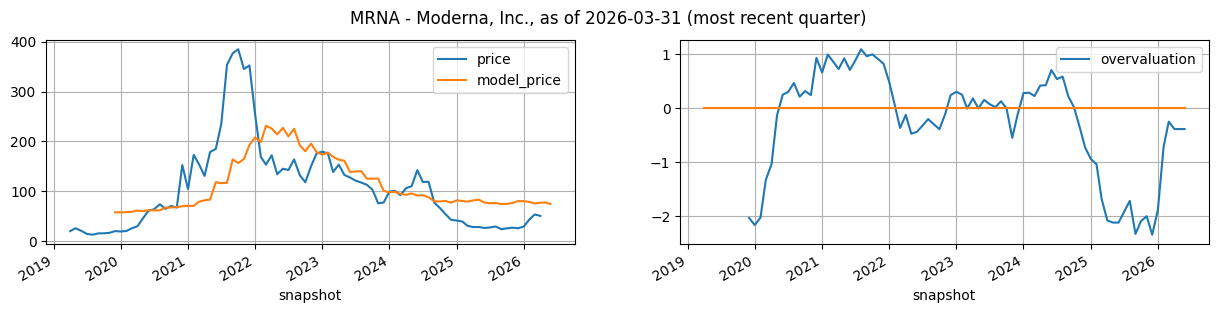

MRNA(0001682852) model_price = 4.855063 * (0.888901 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +56.003954


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,12.135,2.805,-1.978,29.49,0.888901,1.496008,5.022714,4.855063,56.003954,80.389546,-1.875845
2026-02-01,2025-09-30,12.135,2.805,-1.978,44.07,0.888901,1.663449,4.691515,4.855063,56.003954,78.781557,-0.711700
2026-03-01,2025-12-31,12.338,3.688,-1.873,53.57,0.888901,1.726324,4.045860,4.855063,56.003954,75.646860,-0.245800
2026-04-01,2025-12-31,12.338,3.688,-1.873,50.80,0.888901,1.537746,4.399067,4.855063,56.003954,77.361703,-0.383208
2026-05-01,2025-12-31,12.338,3.688,-1.873,NaN,0.888901,1.537746,4.399067,4.855063,56.003954,77.361703,-0.383208
2026-05-26,2026-03-31,11.488,4.080,-1.466,NaN,0.888901,1.537746,3.877364,4.855063,56.003954,74.828798,-0.383208


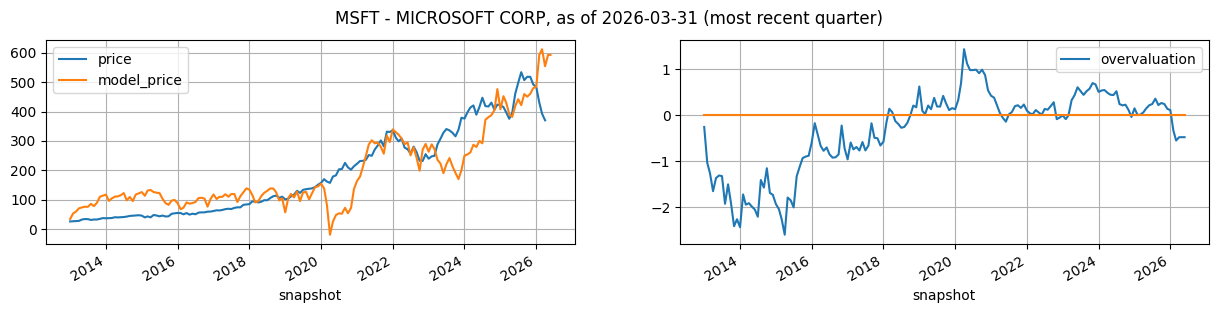

MSFT(0000789019) model_price = 1.906073 * (0.374234 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +131.841904


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,636.351,273.275,147.039,483.62,0.374235,1.496008,184.841059,1.906073,131.841904,484.162471,0.107150
2026-02-01,2025-12-31,665.302,274.427,160.506,430.29,0.374235,1.663449,241.545552,1.906073,131.841904,592.245377,-0.338467
2026-03-01,2025-12-31,665.302,274.427,160.506,392.74,0.374235,1.726324,251.637333,1.906073,131.841904,611.481051,-0.552895
2026-04-01,2025-12-31,665.302,274.427,160.506,370.17,0.374235,1.537746,221.369393,1.906073,131.841904,553.788145,-0.480549
2026-05-01,2026-03-31,694.228,279.861,170.141,NaN,0.374235,1.537746,241.576681,1.906073,131.841904,592.304712,-0.480549
2026-05-26,2026-03-31,694.228,279.861,170.141,NaN,0.374235,1.537746,241.576681,1.906073,131.841904,592.304712,-0.480549


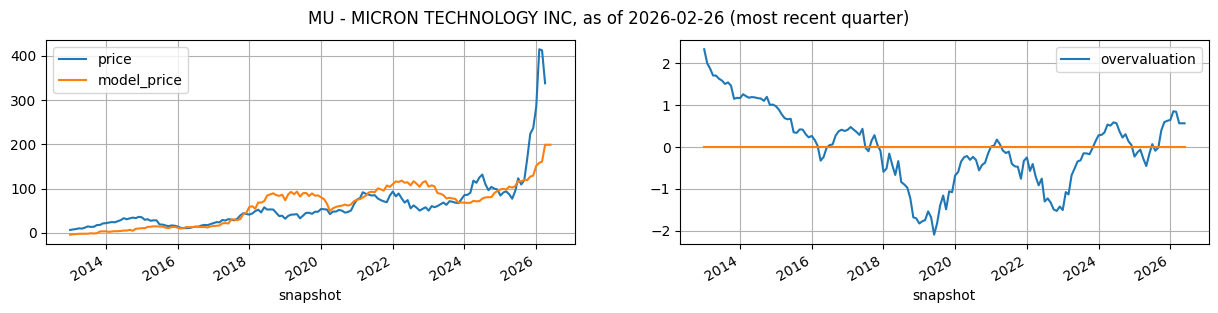

MU(0000723125) model_price = 1.759041 * (1.009211 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -13.039476


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-27,85.971,27.165,22.692,285.41,1.009211,1.496008,93.545291,1.759041,-13.039476,151.510493,0.647439
2026-02-01,2025-11-27,85.971,27.165,22.692,414.88,1.009211,1.663449,97.344863,1.759041,-13.039476,158.194093,0.854329
2026-03-01,2025-11-27,85.971,27.165,22.692,412.37,1.009211,1.726324,98.771617,1.759041,-13.039476,160.703813,0.842699
2026-04-01,2026-02-26,101.509,29.050,30.653,337.84,1.009211,1.537746,120.530513,1.759041,-13.039476,198.978595,0.567035
2026-05-01,2026-02-26,101.509,29.050,30.653,NaN,1.009211,1.537746,120.530513,1.759041,-13.039476,198.978595,0.567035
2026-05-26,2026-02-26,101.509,29.050,30.653,NaN,1.009211,1.537746,120.530513,1.759041,-13.039476,198.978595,0.567035


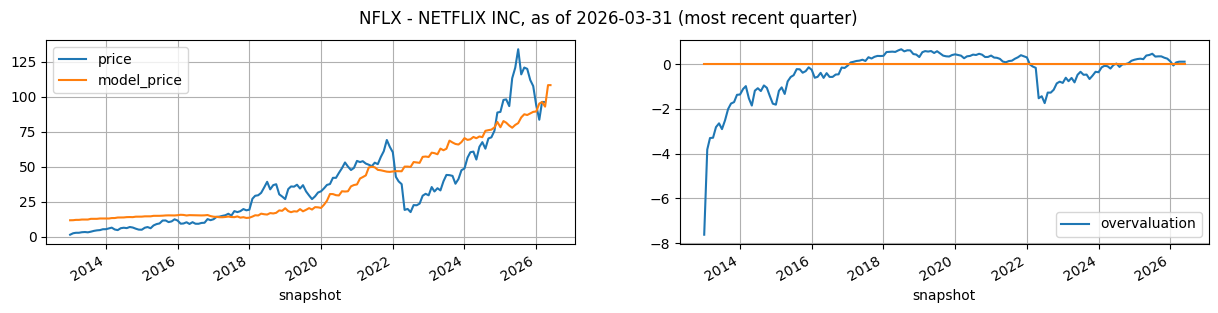

NFLX(0001065280) model_price = 1.718476 * (1.108745 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +9.933840


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,54.934835,28.980800,9.574525,93.76,1.108745,1.496008,46.251497,1.718476,9.93384,89.415930,0.125565
2026-02-01,2025-12-31,55.596993,28.981505,10.149273,83.49,1.108745,1.663449,49.544188,1.718476,9.93384,95.074342,-0.056938
2026-03-01,2025-12-31,55.596993,28.981505,10.149273,96.24,1.108745,1.726324,50.182322,1.718476,9.93384,96.170959,0.080586
2026-04-01,2025-12-31,55.596993,28.981505,10.149273,96.15,1.108745,1.537746,48.268390,1.718476,9.93384,92.881913,0.113394
2026-05-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.108745,1.537746,57.214493,1.718476,9.93384,108.255577,0.113394
2026-05-26,2026-03-31,61.015914,29.889515,12.650279,NaN,1.108745,1.537746,57.214493,1.718476,9.93384,108.255577,0.113394


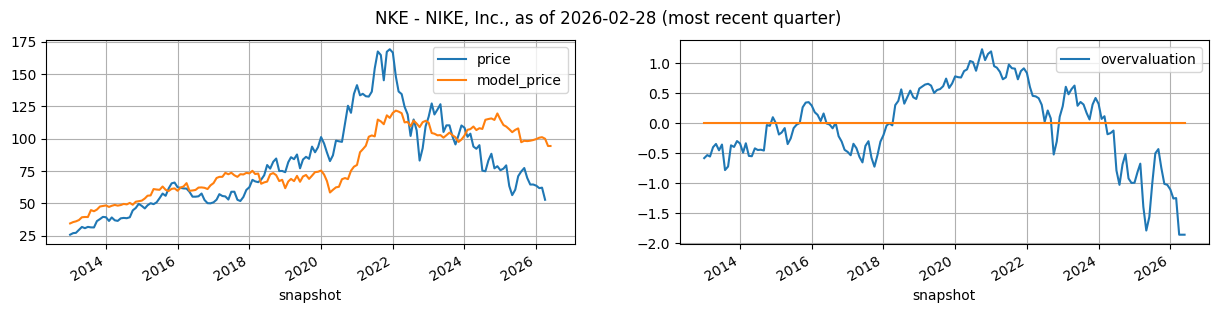

NKE(0000320187) model_price = 2.068662 * (1.867121 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -6.613926


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-30,37.787,23.702,3.056,63.71,1.867121,1.496008,51.422715,2.068662,-6.613926,99.762307,-1.103492
2026-02-01,2025-11-30,37.787,23.702,3.056,61.81,1.867121,1.663449,51.934415,2.068662,-6.613926,100.820841,-1.253203
2026-03-01,2025-11-30,37.787,23.702,3.056,62.18,1.867121,1.726324,52.126560,2.068662,-6.613926,101.218325,-1.245601
2026-04-01,2025-11-30,37.787,23.702,3.056,52.82,1.867121,1.537746,51.550265,2.068662,-6.613926,100.026165,-1.855571
2026-05-01,2026-02-28,37.064,22.974,1.694,NaN,1.867121,1.537746,48.833927,2.068662,-6.613926,94.406978,-1.855571
2026-05-26,2026-02-28,37.064,22.974,1.694,NaN,1.867121,1.537746,48.833927,2.068662,-6.613926,94.406978,-1.855571


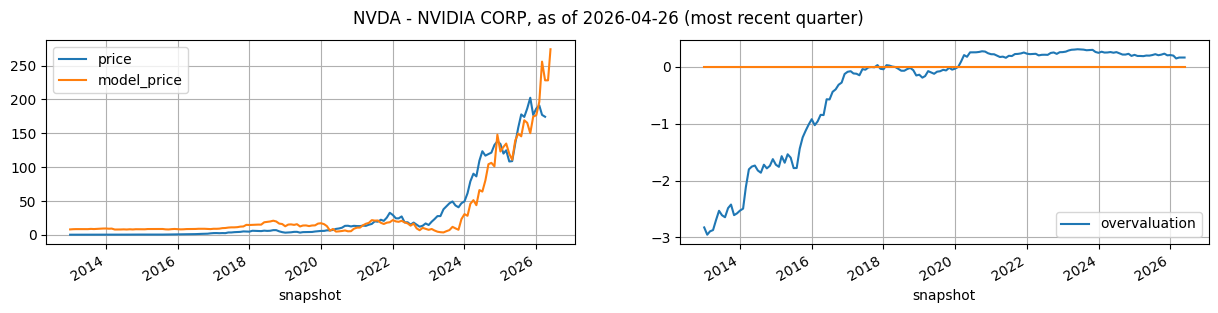

NVDA(0001045810) model_price = 1.425521 * (0.216807 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +9.696311


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-26,161.148,42.251,83.159,186.50,0.216807,1.496008,117.093541,1.425521,9.696311,176.615654,0.209435
2026-02-01,2025-10-26,161.148,42.251,83.159,191.13,0.216807,1.663449,131.017768,1.425521,9.696311,196.464937,0.199705
2026-03-01,2026-01-25,206.803,49.510,102.718,177.19,0.216807,1.726324,172.650863,1.425521,9.696311,255.813802,0.149701
2026-04-01,2026-01-25,206.803,49.510,102.718,174.40,0.216807,1.537746,153.280482,1.425521,9.696311,228.200911,0.165964
2026-05-01,2026-01-25,206.803,49.510,102.718,NaN,0.216807,1.537746,153.280482,1.425521,9.696311,228.200911,0.165964
2026-05-26,2026-04-26,259.474,64.000,125.648,NaN,0.216807,1.537746,185.470428,1.425521,9.696311,274.088366,0.165964


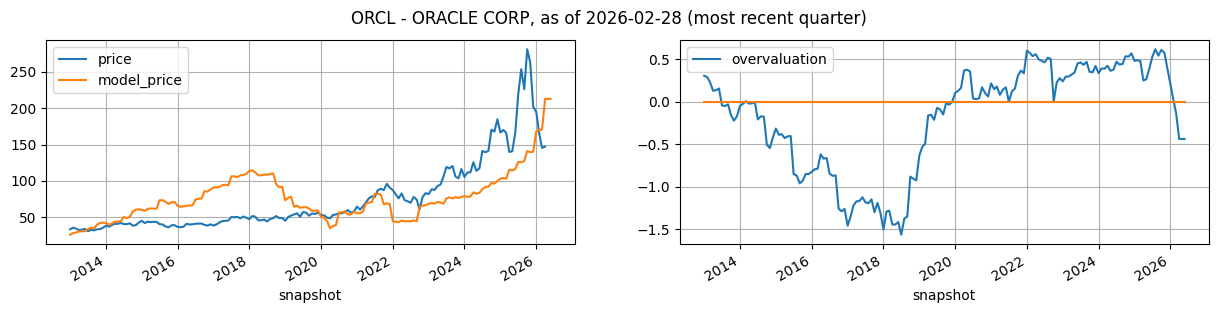

ORCL(0001341439) model_price = 0.558101 * (2.720227 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -64.240680


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-30,204.984,175.033,22.296,194.91,2.720227,1.496008,415.924961,0.558101,-64.24068,167.887261,0.213366
2026-02-01,2025-11-30,204.984,175.033,22.296,164.58,2.720227,1.663449,419.658226,0.558101,-64.24068,169.970798,0.023428
2026-03-01,2025-11-30,204.984,175.033,22.296,145.40,2.720227,1.726324,421.060082,0.558101,-64.24068,170.753174,-0.133504
2026-04-01,2026-02-28,245.240,206.745,23.514,147.11,2.720227,1.537746,496.521964,0.558101,-64.24068,212.868491,-0.435628
2026-05-01,2026-02-28,245.240,206.745,23.514,NaN,2.720227,1.537746,496.521964,0.558101,-64.24068,212.868491,-0.435628
2026-05-26,2026-02-28,245.240,206.745,23.514,NaN,2.720227,1.537746,496.521964,0.558101,-64.24068,212.868491,-0.435628


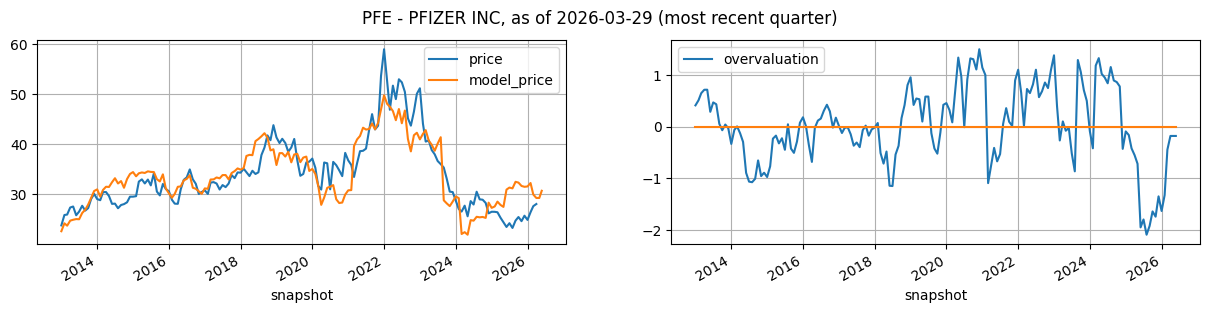

PFE(0000078003) model_price = 0.314505 * (0.020467 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +60.556773


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-28,208.731,115.930,13.077,24.90,0.020467,1.496008,-92.094503,0.314505,60.556773,31.592554,-1.631854
2026-02-01,2025-09-28,208.731,115.930,13.077,26.44,0.020467,1.663449,-89.904877,0.314505,60.556773,32.281203,-1.323581
2026-03-01,2025-12-31,208.160,121.684,11.704,27.65,0.020467,1.726324,-97.218593,0.314505,60.556773,29.981000,-0.443492
2026-04-01,2025-12-31,208.160,121.684,11.704,28.08,0.020467,1.537746,-99.425713,0.314505,60.556773,29.286848,-0.177280
2026-05-01,2025-12-31,208.160,121.684,11.704,NaN,0.020467,1.537746,-99.425713,0.314505,60.556773,29.286848,-0.177280
2026-05-26,2026-03-29,207.618,117.517,11.984,NaN,0.020467,1.537746,-94.839237,0.314505,60.556773,30.729320,-0.177280


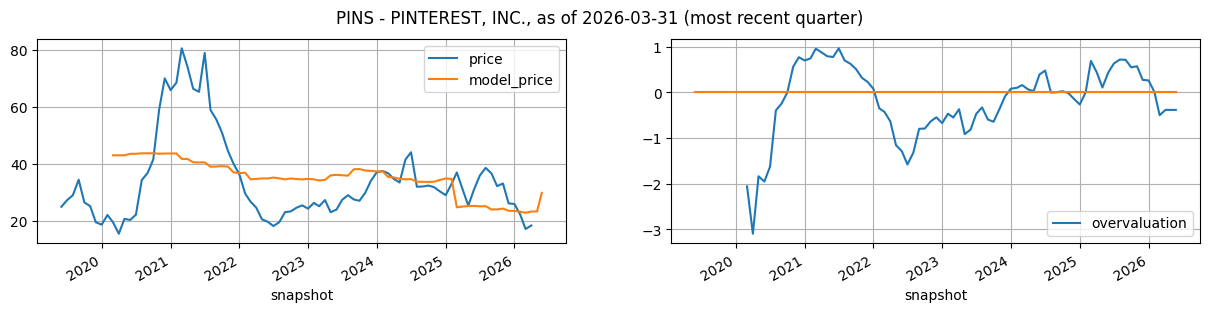

PINS(0001506293) model_price = -1.739202 * (3.148911 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +55.466098


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,5.515410,0.690442,1.147046,25.89,3.148911,1.496008,18.393085,-1.739202,55.466098,23.476813,0.264650
2026-02-01,2025-09-30,5.515410,0.690442,1.147046,22.13,3.148911,1.663449,18.585147,-1.739202,55.466098,23.142778,0.015529
2026-03-01,2025-12-31,5.492132,0.746894,1.284264,17.13,3.148911,1.726324,18.764398,-1.739202,55.466098,22.831025,-0.499020
2026-04-01,2025-12-31,5.492132,0.746894,1.284264,18.34,3.148911,1.537746,18.522214,-1.739202,55.466098,23.252232,-0.382562
2026-05-01,2025-12-31,5.492132,0.746894,1.284264,NaN,3.148911,1.537746,18.522214,-1.739202,55.466098,23.252232,-0.382562
2026-05-26,2026-03-31,4.645279,1.794695,1.248581,NaN,3.148911,1.537746,14.752876,-1.739202,55.466098,29.807870,-0.382562


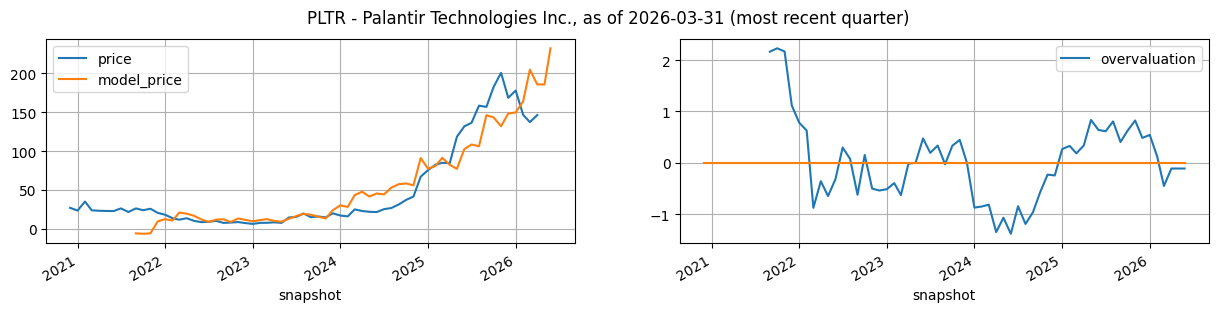

PLTR(0001321655) model_price = 46.938790 * (0.245734 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.077726


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,8.113960,1.523503,1.817505,177.75,0.245734,1.496008,3.189374,46.93879,-0.077726,149.627624,0.543629
2026-02-01,2025-09-30,8.113960,1.523503,1.817505,146.59,0.245734,1.663449,3.493699,46.93879,-0.077726,163.912265,0.120647
2026-03-01,2025-12-31,8.900392,1.513124,2.134473,137.19,0.245734,1.726324,4.358795,46.93879,-0.077726,204.518855,-0.449596
2026-04-01,2025-12-31,8.900392,1.513124,2.134473,146.28,0.245734,1.537746,3.956280,46.93879,-0.077726,185.625280,-0.110149
2026-05-01,2025-12-31,8.900392,1.513124,2.134473,NaN,0.245734,1.537746,3.956280,46.93879,-0.077726,185.625280,-0.110149
2026-05-26,2026-03-31,10.199183,1.749520,2.723375,NaN,0.245734,1.537746,4.944623,46.93879,-0.077726,232.016877,-0.110149


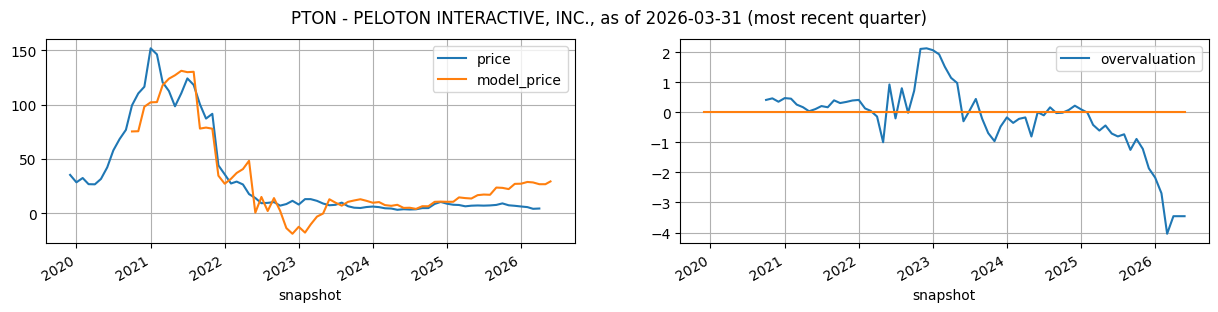

PTON(0001639825) model_price = 24.258054 * (1.444104 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.071920


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,2.1701,2.5171,0.3924,6.16,1.444104,1.496008,1.203783,24.258054,-2.07192,27.129515,-2.174403
2026-02-01,2025-09-30,2.1701,2.5171,0.3924,5.59,1.444104,1.663449,1.269487,24.258054,-2.07192,28.723363,-2.694479
2026-03-01,2025-12-31,2.1646,2.4913,0.3576,4.02,1.444104,1.726324,1.251940,24.258054,-2.07192,28.297717,-4.040972
2026-04-01,2025-12-31,2.1646,2.4913,0.3576,4.29,1.444104,1.537746,1.184505,24.258054,-2.07192,26.661861,-3.457045
2026-05-01,2025-12-31,2.1646,2.4913,0.3576,NaN,1.444104,1.537746,1.184505,24.258054,-2.07192,26.661861,-3.457045
2026-05-26,2026-03-31,2.0174,2.2593,0.4136,NaN,1.444104,1.537746,1.290046,24.258054,-2.07192,29.222097,-3.457045


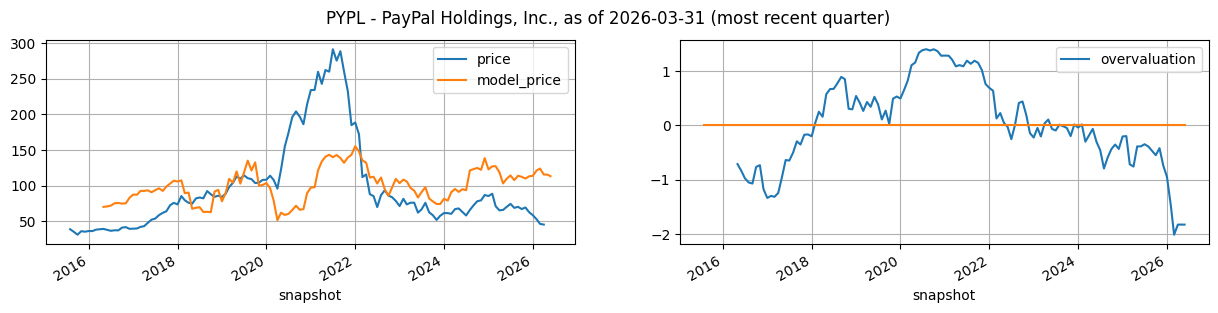

PYPL(0001633917) model_price = 6.949500 * (0.829442 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +1.188889


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,79.801,59.603,6.426,58.38,0.829442,1.496008,16.200661,6.9495,1.188889,113.775389,-0.943546
2026-02-01,2025-09-30,79.801,59.603,6.426,52.69,0.829442,1.663449,17.276637,6.9495,1.188889,121.252884,-1.455224
2026-03-01,2025-12-31,80.173,59.917,6.416,46.21,0.829442,1.726324,17.657960,6.9495,1.188889,123.902886,-2.007088
2026-04-01,2025-12-31,80.173,59.917,6.416,45.23,0.829442,1.537746,16.448041,6.9495,1.188889,115.494560,-1.821504
2026-05-01,2025-12-31,80.173,59.917,6.416,NaN,0.829442,1.537746,16.448041,6.9495,1.188889,115.494560,-1.821504
2026-05-26,2026-03-31,80.546,60.522,6.390,NaN,0.829442,1.537746,16.112442,6.9495,1.188889,113.162311,-1.821504


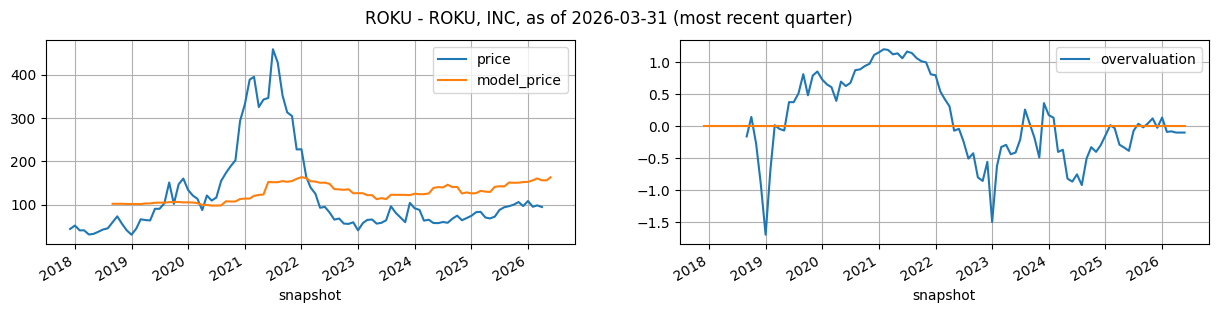

ROKU(0001428439) model_price = 47.042387 * (0.495512 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +101.503709


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,4.397285,1.772199,0.455360,108.49,0.495512,1.496008,1.087932,47.042387,101.503709,152.682607,0.136445
2026-02-01,2025-09-30,4.397285,1.772199,0.455360,95.20,0.495512,1.663449,1.164178,47.042387,101.503709,156.269398,-0.088387
2026-03-01,2025-12-31,4.433483,1.775538,0.483718,98.41,0.495512,1.726324,1.256361,47.042387,101.503709,160.605921,-0.079287
2026-04-01,2025-12-31,4.433483,1.775538,0.483718,94.62,0.495512,1.537746,1.165142,47.042387,101.503709,156.314776,-0.098510
2026-05-01,2025-12-31,4.433483,1.775538,0.483718,NaN,0.495512,1.537746,1.165142,47.042387,101.503709,156.314776,-0.098510
2026-05-26,2026-03-31,4.352634,1.681570,0.544126,NaN,0.495512,1.537746,1.311941,47.042387,101.503709,163.220527,-0.098510


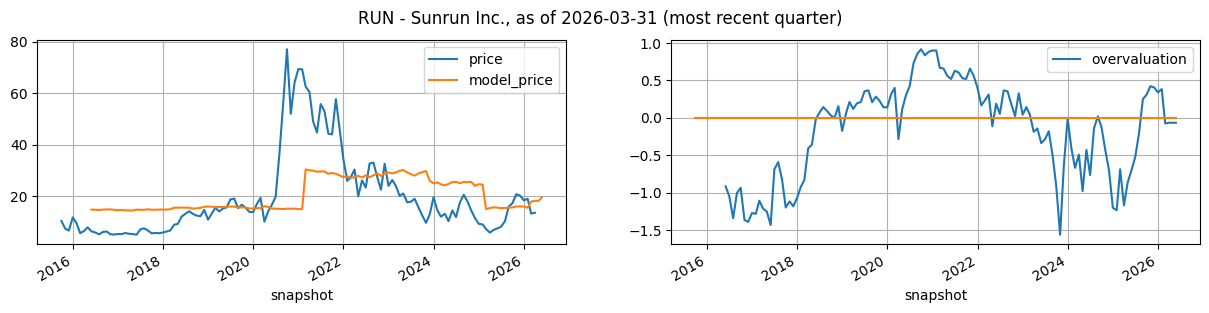

RUN(0001469367) model_price = 3.439617 * (0.948012 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.680749


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,22.225482,19.241580,-0.776747,18.40,0.948013,1.496008,0.666436,3.439617,13.680749,15.973032,0.341277
2026-02-01,2025-09-30,22.225482,19.241580,-0.776747,19.00,0.948013,1.663449,0.536376,3.439617,13.680749,15.525678,0.385028
2026-03-01,2025-12-31,22.610596,19.478112,-0.421440,13.25,0.948013,1.726324,1.229474,3.439617,13.680749,17.909670,-0.073906
2026-04-01,2025-12-31,22.610596,19.478112,-0.421440,13.56,0.948013,1.537746,1.308949,3.439617,13.680749,18.183031,-0.064684
2026-05-01,2025-12-31,22.610596,19.478112,-0.421440,NaN,0.948013,1.537746,1.308949,3.439617,13.680749,18.183031,-0.064684
2026-05-26,2026-03-31,22.765093,19.424339,-0.306611,NaN,0.948013,1.537746,1.685765,3.439617,13.680749,19.479134,-0.064684


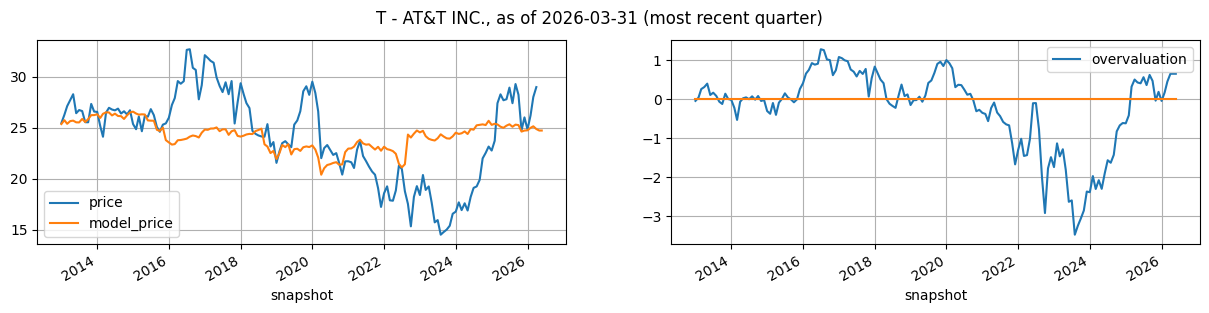

T(0000732717) model_price = 0.035378 * (0.016551 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.830531


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,423.213,296.458,40.860,24.84,0.016551,1.496008,-228.326446,0.035378,32.830531,24.752848,-0.044789
2026-02-01,2025-09-30,423.213,296.458,40.860,26.21,0.016551,1.663449,-221.484807,0.035378,32.830531,24.994890,0.170652
2026-03-01,2025-12-31,420.198,293.707,40.284,28.01,0.016551,1.726324,-217.209007,0.035378,32.830531,25.146158,0.451607
2026-04-01,2025-12-31,420.198,293.707,40.284,28.99,0.016551,1.537746,-224.805693,0.035378,32.830531,24.877404,0.650794
2026-05-01,2026-03-31,421.188,295.569,38.792,NaN,0.016551,1.537746,-228.945624,0.035378,32.830531,24.730943,0.650794
2026-05-26,2026-03-31,421.188,295.569,38.792,NaN,0.016551,1.537746,-228.945624,0.035378,32.830531,24.730943,0.650794


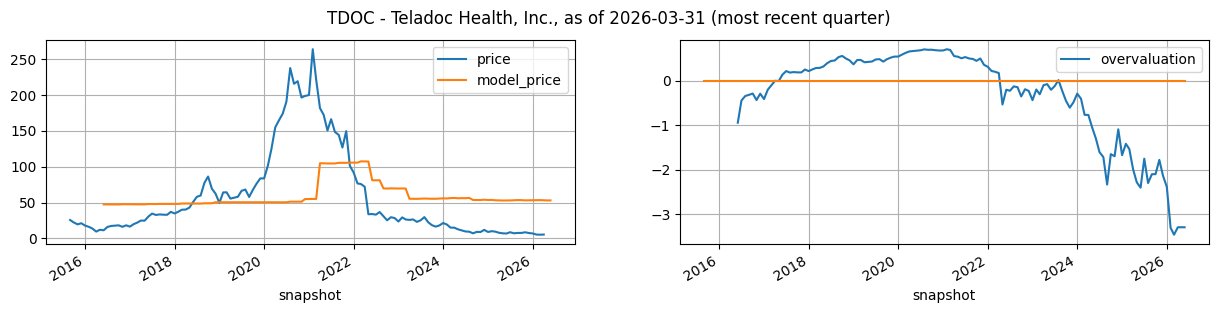

TDOC(0001477449) model_price = 4.377277 * (0.854549 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.053358


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,2.878547,1.486432,0.292517,7.00,0.854549,1.496008,1.411035,4.377277,47.053358,53.229851,-2.381011
2026-02-01,2025-09-30,2.878547,1.486432,0.292517,5.45,0.854549,1.663449,1.460015,4.377277,47.053358,53.444248,-3.300650
2026-03-01,2025-12-31,2.858300,1.472594,0.294357,5.26,0.854549,1.726324,1.478119,4.377277,47.053358,53.523495,-3.454876
2026-04-01,2025-12-31,2.858300,1.472594,0.294357,5.45,0.854549,1.537746,1.422610,4.377277,47.053358,53.280516,-3.288103
2026-05-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.854549,1.537746,1.370797,4.377277,47.053358,53.053718,-3.288103
2026-05-26,2026-03-31,2.807261,1.470945,0.287954,NaN,0.854549,1.537746,1.370797,4.377277,47.053358,53.053718,-3.288103


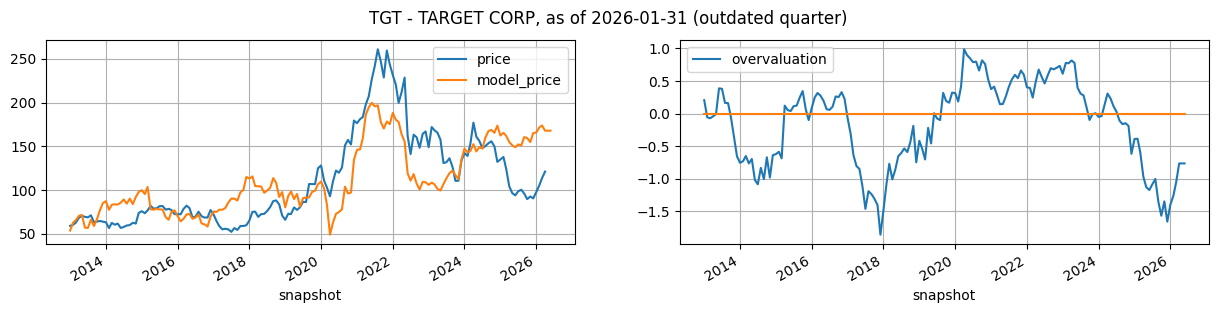

TGT(0000027419) model_price = 5.192207 * (1.413170 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -96.007833


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-01,59.991,44.490,6.774,97.75,1.41317,1.496008,50.421461,5.192207,-96.007833,165.790822,-1.396793
2026-02-01,2025-11-01,59.991,44.490,6.774,105.47,1.41317,1.663449,51.555706,5.192207,-96.007833,171.680058,-1.257369
2026-03-01,2025-11-01,59.991,44.490,6.774,113.79,1.41317,1.726324,51.981620,5.192207,-96.007833,173.891491,-1.054109
2026-04-01,2026-01-31,59.490,43.325,6.562,121.20,1.41317,1.537746,50.835191,5.192207,-96.007833,167.938992,-0.763162
2026-05-01,2026-01-31,59.490,43.325,6.562,NaN,1.41317,1.537746,50.835191,5.192207,-96.007833,167.938992,-0.763162
2026-05-26,2026-01-31,59.490,43.325,6.562,NaN,1.41317,1.537746,50.835191,5.192207,-96.007833,167.938992,-0.763162


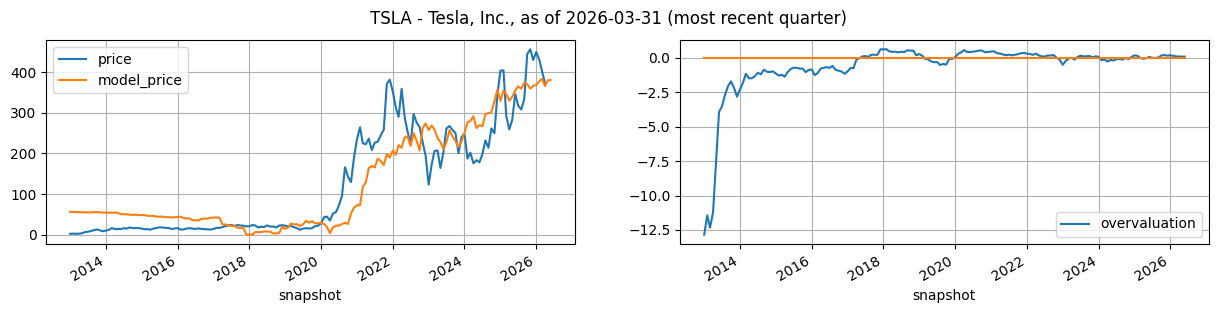

TSLA(0001318605) model_price = 6.473380 * (0.586283 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +56.274501


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,133.735,53.765,15.748,449.72,0.586283,1.496008,48.200657,6.47338,56.274501,368.295649,0.183873
2026-02-01,2025-12-31,137.806,55.669,14.747,430.41,0.586283,1.663449,49.655163,6.47338,56.274501,377.711215,0.152185
2026-03-01,2025-12-31,137.806,55.669,14.747,402.51,0.586283,1.726324,50.582377,6.47338,56.274501,383.713426,0.111240
2026-04-01,2025-12-31,137.806,55.669,14.747,371.75,0.586283,1.537746,47.801414,6.47338,56.274501,365.711195,0.094776
2026-05-01,2026-03-31,143.724,59.608,16.528,NaN,0.586283,1.537746,50.070760,6.47338,56.274501,380.401535,0.094776
2026-05-26,2026-03-31,143.724,59.608,16.528,NaN,0.586283,1.537746,50.070760,6.47338,56.274501,380.401535,0.094776


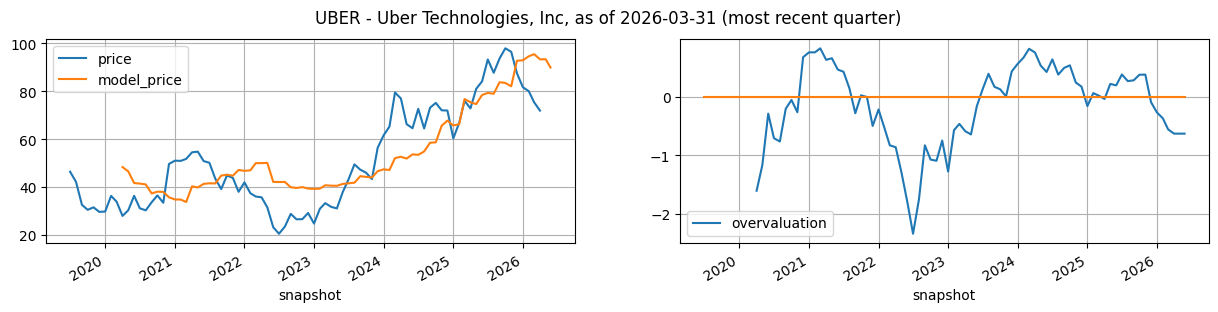

UBER(0001543151) model_price = 1.126317 * (1.418231 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.315077


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,63.344,35.210,8.966,81.71,1.418231,1.496008,68.039649,1.126317,16.315077,92.949262,-0.264578
2026-02-01,2025-09-30,63.344,35.210,8.966,80.05,1.418231,1.663449,69.540925,1.126317,16.315077,94.640174,-0.365896
2026-03-01,2025-12-31,61.802,34.761,10.099,75.42,1.418231,1.726324,70.322673,1.126317,16.315077,95.520670,-0.556812
2026-04-01,2025-12-31,61.802,34.761,10.099,71.93,1.418231,1.537746,68.418222,1.126317,16.315077,93.375654,-0.628485
2026-05-01,2025-12-31,61.802,34.761,10.099,NaN,1.418231,1.537746,68.418222,1.126317,16.315077,93.375654,-0.628485
2026-05-26,2026-03-31,59.885,35.134,10.126,NaN,1.418231,1.537746,65.367991,1.126317,16.315077,89.940129,-0.628485


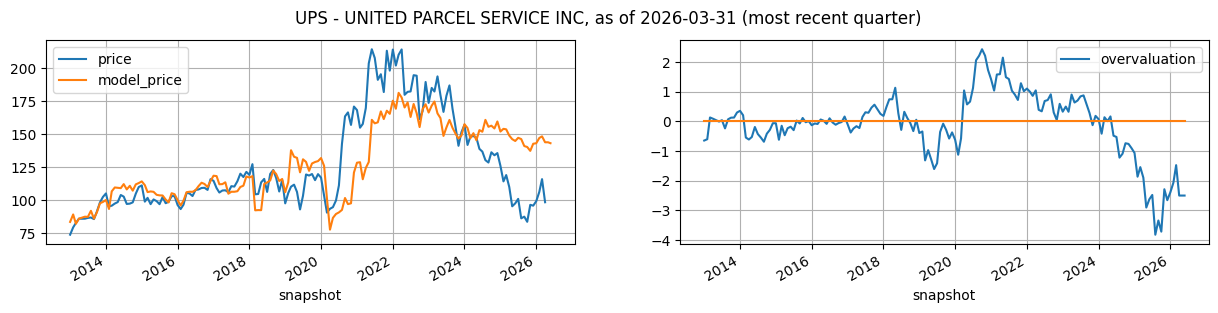

UPS(0001090727) model_price = 2.816274 * (0.718794 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +119.523828


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,71.392,55.569,8.463,99.19,0.718794,1.496008,8.407879,2.816274,119.523828,143.202714,-2.392878
2026-02-01,2025-09-30,71.392,55.569,8.463,106.22,0.718794,1.663449,9.824932,2.816274,119.523828,147.193524,-2.068367
2026-03-01,2025-12-31,73.090,56.863,8.450,115.96,0.718794,1.726324,10.261112,2.816274,119.523828,148.421926,-1.476194
2026-04-01,2025-12-31,73.090,56.863,8.450,98.38,0.718794,1.537746,8.667626,2.816274,119.523828,143.934233,-2.501026
2026-05-01,2025-12-31,73.090,56.863,8.450,NaN,0.718794,1.537746,8.667626,2.816274,119.523828,143.934233,-2.501026
2026-05-26,2026-03-31,71.809,56.046,8.356,NaN,0.718794,1.537746,8.419302,2.816274,119.523828,143.234886,-2.501026


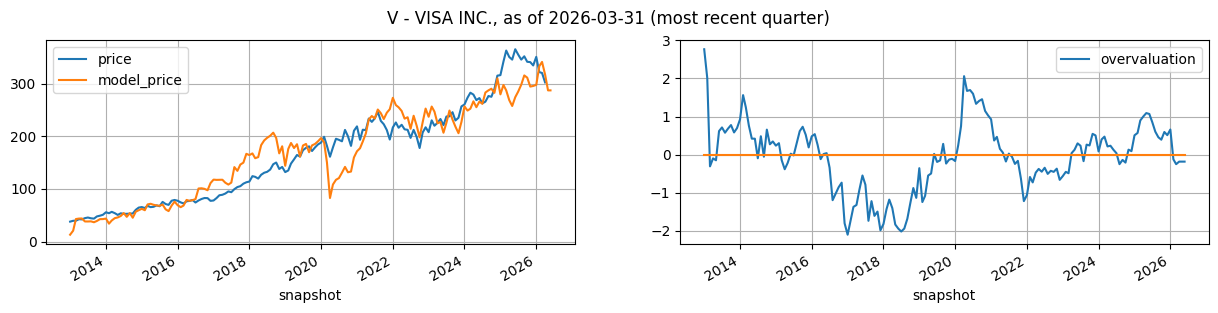

V(0001403161) model_price = 5.183934 * (1.053816 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -105.675481


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,99.627,61.718,23.059,350.71,1.053816,1.496008,77.766987,5.183934,-105.675481,297.463463,0.660925
2026-02-01,2025-12-31,96.814,58.037,24.443,321.83,1.053816,1.663449,84.646838,5.183934,-105.675481,333.128160,-0.121249
2026-03-01,2025-12-31,96.814,58.037,24.443,320.14,1.053816,1.726324,86.183687,5.183934,-105.675481,341.095082,-0.248242
2026-04-01,2025-12-31,96.814,58.037,24.443,302.24,1.053816,1.537746,81.574268,5.183934,-105.675481,317.200162,-0.181468
2026-05-01,2026-03-31,95.049,59.388,22.756,NaN,1.053816,1.537746,75.769106,5.183934,-105.675481,287.106582,-0.181468
2026-05-26,2026-03-31,95.049,59.388,22.756,NaN,1.053816,1.537746,75.769106,5.183934,-105.675481,287.106582,-0.181468


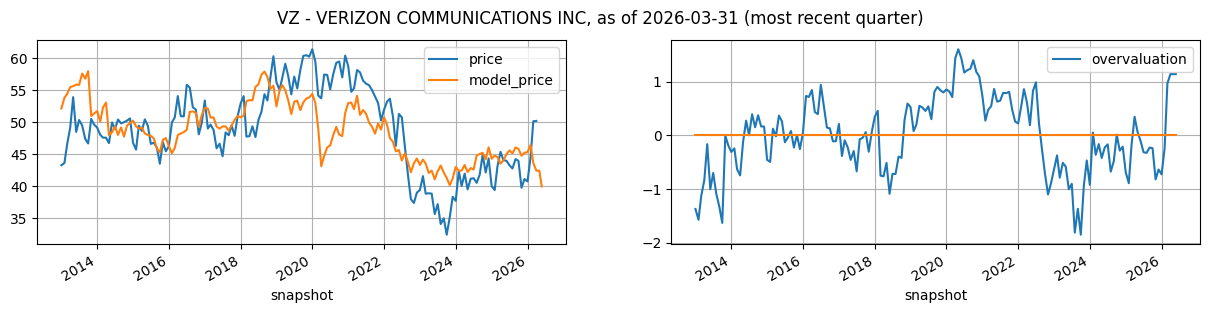

VZ(0000732712) model_price = 0.171741 * (0.006124 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +83.459573


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,388.331,281.986,38.455,40.73,0.006124,1.496008,-222.078851,0.171741,83.459573,45.319419,-0.725717
2026-02-01,2025-09-30,388.331,281.986,38.455,44.52,0.006124,1.663449,-215.639907,0.171741,83.459573,46.425253,-0.237751
2026-03-01,2025-12-31,404.258,298.517,37.137,50.14,0.006124,1.726324,-231.930814,0.171741,83.459573,43.627428,0.968016
2026-04-01,2025-12-31,404.258,298.517,37.137,50.20,0.006124,1.537746,-238.934045,0.171741,83.459573,42.424683,1.142573
2026-05-01,2025-12-31,404.258,298.517,37.137,NaN,0.006124,1.537746,-238.934045,0.171741,83.459573,42.424683,1.142573
2026-05-26,2026-03-31,417.882,313.260,37.339,NaN,0.006124,1.537746,-253.282986,0.171741,83.459573,39.960374,1.142573


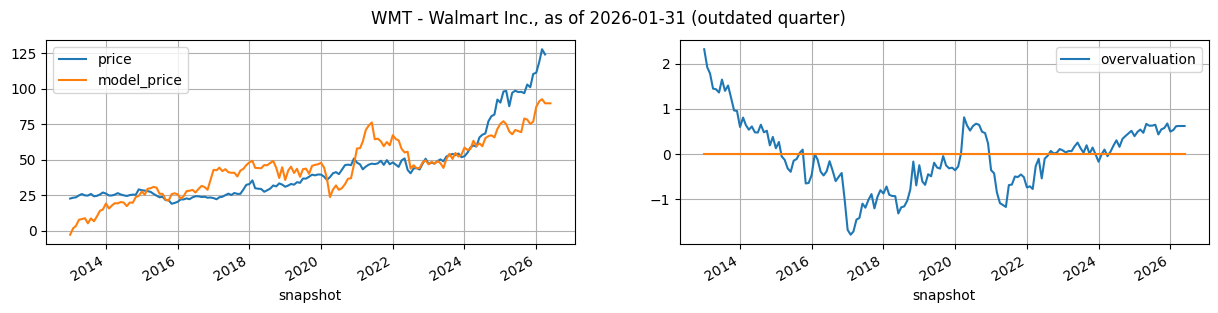

WMT(0000104169) model_price = 0.566725 * (1.460954 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -77.184520


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-31,288.655,192.561,40.977,111.41,1.460954,1.496008,290.452520,0.566725,-77.18452,87.422206,0.497696
2026-02-01,2025-10-31,288.655,192.561,40.977,119.14,1.460954,1.663449,297.313750,0.566725,-77.18452,91.310637,0.534426
2026-03-01,2025-10-31,288.655,192.561,40.977,127.95,1.460954,1.726324,299.890171,0.566725,-77.18452,92.770760,0.617557
2026-04-01,2026-01-31,284.668,185.051,41.565,124.28,1.460954,1.537746,294.752172,0.566725,-77.18452,89.858927,0.621615
2026-05-01,2026-01-31,284.668,185.051,41.565,NaN,1.460954,1.537746,294.752172,0.566725,-77.18452,89.858927,0.621615
2026-05-26,2026-01-31,284.668,185.051,41.565,NaN,1.460954,1.537746,294.752172,0.566725,-77.18452,89.858927,0.621615


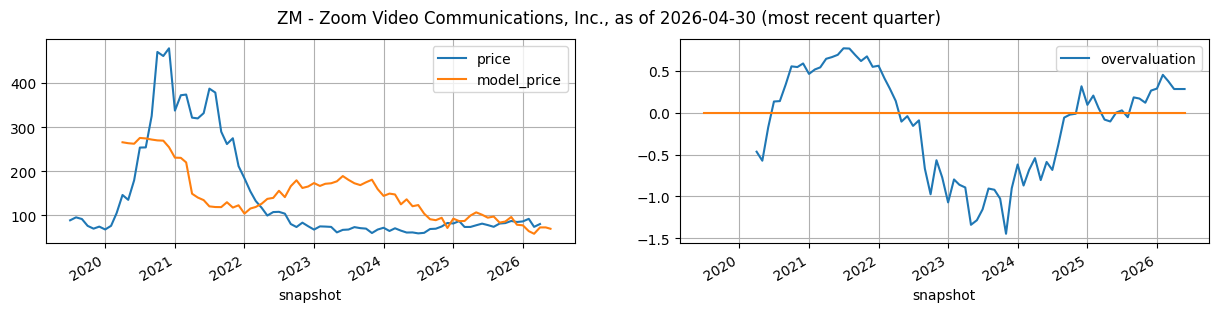

ZM(0001585521) model_price = -38.340180 * (0.340593 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +263.623499


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-31,11.390811,2.103971,2.059093,86.29,0.340593,1.496008,4.856074,-38.34018,263.623499,77.440731,0.286634
2026-02-01,2025-10-31,11.390811,2.103971,2.059093,92.10,0.340593,1.663449,5.200851,-38.34018,263.623499,64.221933,0.450404
2026-03-01,2026-01-31,11.960416,2.152158,1.989048,73.94,0.340593,1.726324,5.355212,-38.34018,263.623499,58.303708,0.375760
2026-04-01,2026-01-31,11.960416,2.152158,1.989048,80.39,0.340593,1.537746,4.980121,-38.34018,263.623499,72.684772,0.281148
2026-05-01,2026-01-31,11.960416,2.152158,1.989048,NaN,0.340593,1.537746,4.980121,-38.34018,263.623499,72.684772,0.281148
2026-05-26,2026-04-30,12.162017,2.190869,2.021397,NaN,0.340593,1.537746,5.059818,-38.34018,263.623499,69.629161,0.281148


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    quarters_since_last_report = (datetime.today() - df['date'].max()) / timedelta(days=7) / 13
    caption = f"{ticker} - {name}"
    caption += f", as of {df['date'].max():%Y-%m-%d} ({"most recent" if quarters_since_last_report < 1 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    df[['price','model_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{}({}) model_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, cik, df['hype'].mean(), df['asmul'].mean(),
        "+" if df['bias'].mean() >= 0 else "", df['bias'].mean()
    ))

    # Display a few most recent records from the result set
    display(df.drop(columns=['cik','ticker']).tail(6))

for i in result[result.index.isin(sample_tickers, level='ticker')].groupby(by=['ticker','cik']):
    plot_ticker(i)

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together, as shown below. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

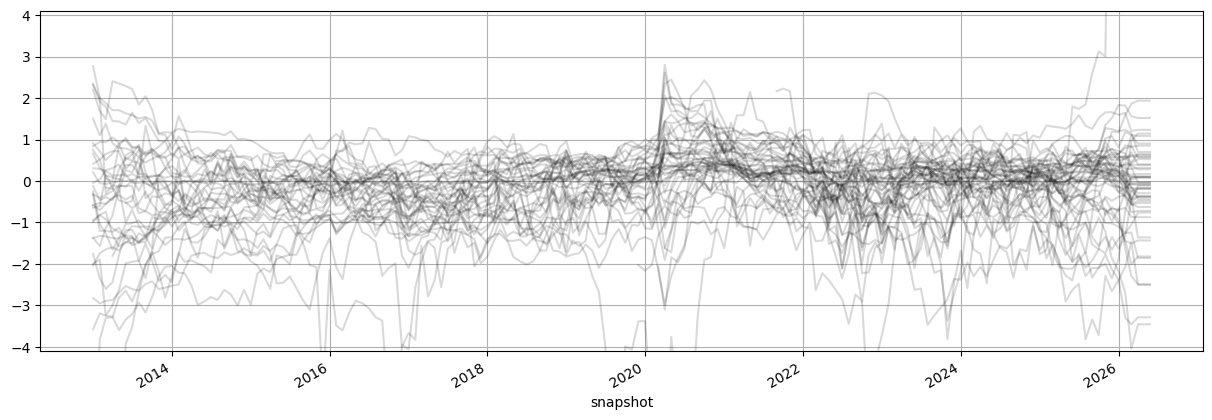

In [18]:
pd.pivot_table(result[result.index.isin(sample_tickers, level='ticker')],
               index='snapshot', columns='ticker', values='overvaluation').plot(
               grid=True, legend=False, c='black', alpha=0.15, figsize=(15,5),ylim=(-4.1,4.1))
plt.show()

In [19]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.